# 📊 Statistics & Visualisation for Immoeliza data analysis

### Installation
Before starting,  run the command below in your terminal.

```bash
pip install matplotlib seaborn plotly scipy statsmodels
```

The most common Python visualization libraries are:
- `matplotlib`
- `seaborn `
- `plotly`

The will have similar types of visuals in offer but the syntax is different. And, two useful statistical libraries are:
- `scipy`
- `stastsmodels`

In the code block below, we are updating parameters in the library to ensure a consistent style. You don't need to do this but it can lead to having a nicer and consistent figures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── Shared style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})

# ── Colour palette we'll reuse ────────────────────────────────────────────────
BLUE   = '#2166ac'
ORANGE = '#d6604d'
GREEN  = '#4dac26'
GREY   = '#878787'
PALETTE = [BLUE, ORANGE, GREEN, '#9970ab', '#bf812d']

print("Libraries loaded ✅")
print(f"  matplotlib {plt.matplotlib.__version__}")
print(f"  seaborn    {sns.__version__}")


Libraries loaded ✅
  matplotlib 3.11.0
  seaborn    0.13.2


# Dataset

In [2]:
dfr = pd.read_csv("../Data/Clean/RentCleanForAnalysis.csv")
dfs = pd.read_csv("../Data/Clean/SaleCleanForAnalysis.csv")

## Questions

### 1 How many observations and features/columns do you have?

In [7]:
print(f"Dataset loaded: {dfr.shape[0]} properties to rent × {dfr.shape[1]} columns")
print(f"{len(dfr[dfr["property_type"]=="House"])/len(dfr)*100:.1f} % houses - " \
      f"{len(dfr[dfr["property_type"]=="Appartment"])/len(dfr)*100:.1f} % apartments")
print("-"*20)
print(f"Dataset loaded: {dfs.shape[0]} properties for sale × {dfs.shape[1]} columns")
print(f"{len(dfs[dfs["property_type"]=="House"])/len(dfs)*100:.1f} % houses - " \
      f"{len(dfs[dfs["property_type"]=="Appartment"])/len(dfs)*100:.1f} % apartments")


Dataset loaded: 3795 properties to rent × 26 columns
23.3 % houses - 76.7 % apartments
--------------------
Dataset loaded: 9705 properties for sale × 26 columns
66.5 % houses - 33.5 % apartments


### 2 What is the proportion of missing values per column?

Bar chart with proportion of values for each column

['longitude', 'latitude', 'transaction_type', 'price', 'property_type', 'property_subtype', 'seller_id', 'postal_code', 'date_of_construction', 'property_condition', 'livable_surface', 'number_of_bedrooms', 'number_of_bathrooms', 'elevator', 'terrace', 'furnished', 'availability', 'province', 'street', 'street_number', 'garage', 'land_surface', 'energy_consumption', 'garden', 'balcony', 'swimming_pool']


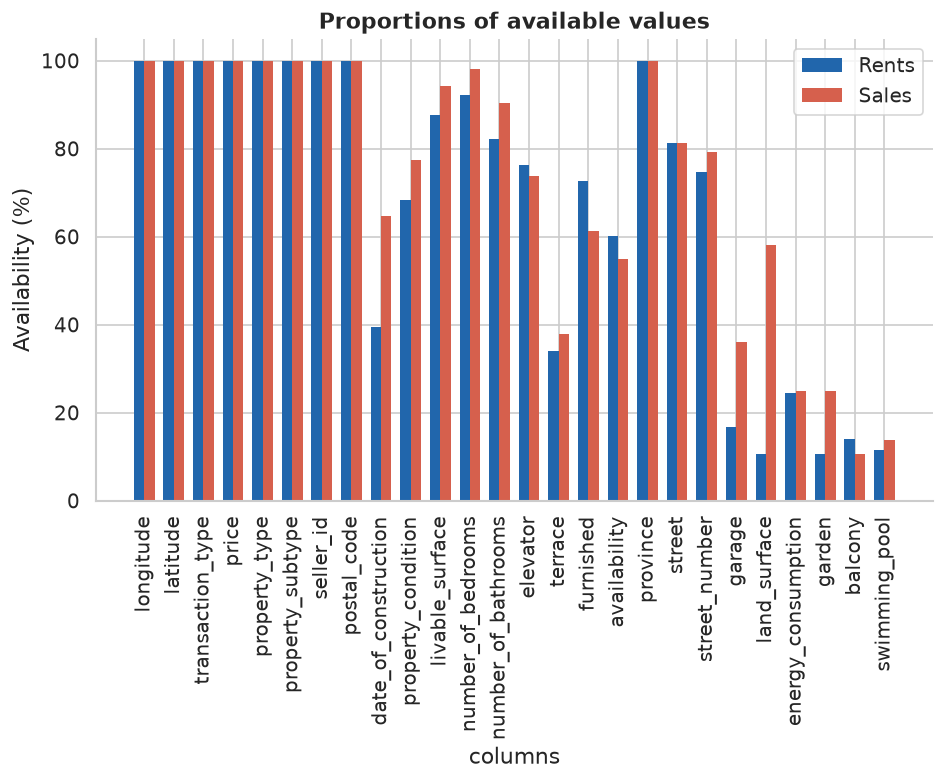

In [8]:
# define values
cats = list(dfr.columns)
print(cats)
valsR = (1-dfr.isnull().sum()/len(dfr))*100
valsS = (1-dfs.isnull().sum()/len(dfs))*100

# plot
x = np.arange(len(cats))
width = 0.35
plt.bar(x - width/2, valsR, width, color=BLUE,label="Rents", edgecolor=None, linewidth=0)
plt.bar(x + width/2, valsS, width, color=ORANGE,label="Sales", edgecolor=None, linewidth=0)
plt.xticks(x,cats,rotation=90)
plt.title('Proportions of available values')
plt.xlabel("columns")
plt.ylabel("Availability (%)")
plt.legend()
plt.show()


## 3 Which variables would you delete and why?

Keep only data that is available in more than 60% : 'longitude', 'latitude', 'transaction_type', 'price', 'property_type', 'property_subtype', 'seller_id', 'postal_code', 'property_condition', 'livable_surface', 'number_of_bedrooms', 'number_of_bathrooms', 'elevator', 'furnished', 'province', 'street', 'street_number'

In [9]:
dfr = dfr[['longitude', 'latitude', 'transaction_type', 'price', 'property_type', 'property_subtype', \
           'seller_id', 'postal_code', 'property_condition', 'livable_surface', 'number_of_bedrooms', \
            'number_of_bathrooms', 'elevator', 'furnished', 'province', 'street', 'street_number']]
print(dfr.shape)
dfs = dfs[['longitude', 'latitude', 'transaction_type', 'price', 'property_type', 'property_subtype', \
           'seller_id', 'postal_code', 'property_condition', 'livable_surface', 'number_of_bedrooms', \
            'number_of_bathrooms', 'elevator', 'furnished', 'province', 'street', 'street_number']]
print(dfs.shape)

(3795, 17)
(9705, 17)


## 4 What variables are most subject to outliers?

Build box plots with outliers

Index(['Hainaut', 'Liège', 'Namur', 'Luxembourg', 'West vlaanderen', 'Limburg',
       'Antwerp', 'Oost vlaanderen', 'Brussels', 'Vlaams brabant',
       'Brabant wallon'],
      dtype='str', name='province')


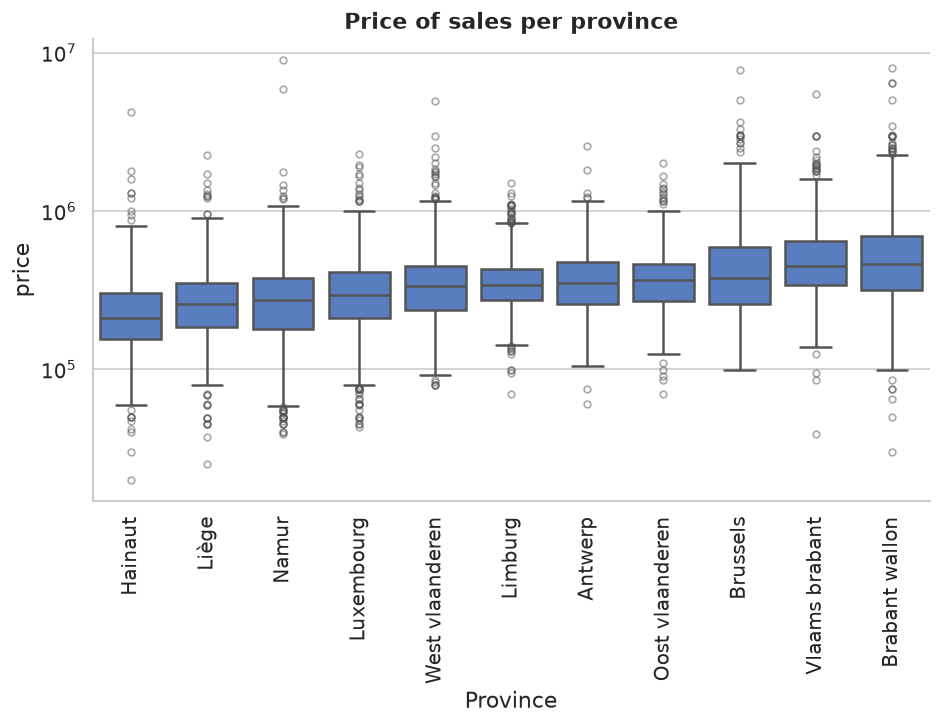

Index(['Hainaut', 'Luxembourg', 'Liège', 'Namur', 'West vlaanderen',
       'Oost vlaanderen', 'Limburg', 'Antwerp', 'Brabant wallon', 'Brussels',
       'Vlaams brabant'],
      dtype='str', name='province')


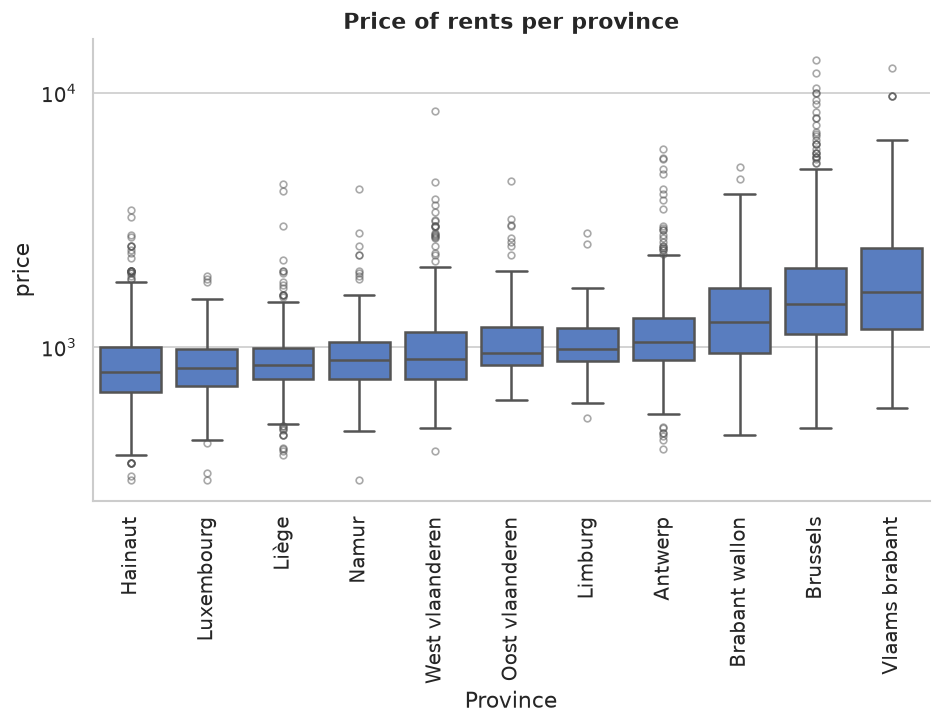

In [10]:
# boxplot() creates a box plot, data_box contains the data for each category, labels specify the category names, patch_artist=True allows customizing the appearance of the boxes

# investigate subcategory repartition
'''
cats = list(dfr["property_subtype"].astype("category").cat.categories)
for cat in cats:
    nb_sub_cat = len(dfr[dfr["property_subtype"]==cat])
    print(f"{cat} : {nb_sub_cat/len(dfr)*100:.2f}")

Sale
Bungalow : 0.80
Chalet : 0.84
Cottage : 0.61
Duplex : 1.67
Flat : 26.87
FlatStudio : 1.49
GroundFloor : 1.73
House : 54.90
Loft : 0.25
Mansion : 0.06
MasterHouse : 0.61
MixedBuilding : 2.37
Penthouse : 1.21
Triplex : 0.30
Villa : 6.28
-------
Rent
Bungalow : 0.18
Chalet : 0.05
Cottage : 0.13
Duplex : 4.90
Flat : 61.18
FlatStudio : 5.35
GroundFloor : 2.53
House : 19.91
Loft : 0.55
MasterHouse : 0.32
MixedBuilding : 0.18
Penthouse : 1.53
Triplex : 0.63
Villa : 2.55
'''

# boxplot that shows the price of properties for sale per province
order = list(dfs["province"].astype("category").cat.categories)
median_price_per_province = dfs.groupby("province")["price"].median().sort_values()
print(median_price_per_province.index)

sns.boxplot(data=dfs, x='province', y='price', log_scale=True, order=median_price_per_province.index,
            linewidth=1.5,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
plt.title('Price of sales per province')
plt.xlabel('Province')
plt.xticks(rotation=90)
plt.show()

# boxplot that shows the price of properties for rent per province
median_price_per_province = dfr.groupby("province")["price"].median().sort_values()
print(median_price_per_province.index)

sns.boxplot(data=dfr, x='province', y='price', log_scale=True, order=median_price_per_province.index,
            linewidth=1.5,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
plt.title('Price of rents per province')
plt.xlabel('Province')
plt.xticks(rotation=90)
plt.show()

#for corrolation between numeric x category : pearson or spearman

## 6 What is the correlation between the variables and the price? Why do you think some variables are more correlated than others?

Heatmap + pearson (-1 -> 1) or spearman (-1 -> 1, less affected by outliers) for numerical  
Boxplots per category for categorical

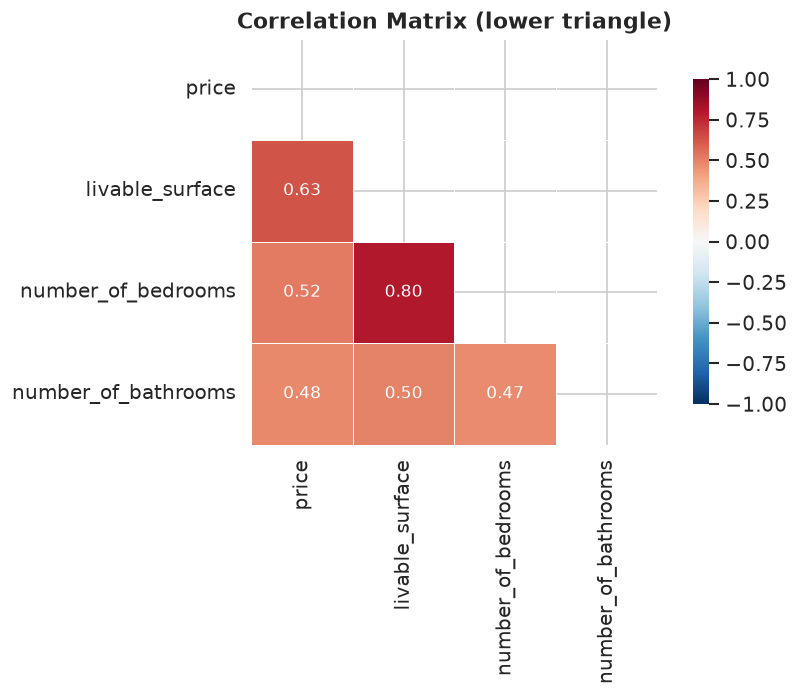

Top 5 correlations:
               var1            var2        r
 number_of_bedrooms livable_surface 0.801282
    livable_surface           price 0.627650
 number_of_bedrooms           price 0.522754
number_of_bathrooms livable_surface 0.498726
number_of_bathrooms           price 0.480888
Pearson r = 0.658  (p = 0.00e+00)
→ Moderate positive correlation — livable_surface predicts price but not perfectly.


In [11]:
numerical = dfs[['price', 'livable_surface', 'number_of_bedrooms', 'number_of_bathrooms']]
corr = numerical.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

ax.set_title('Correlation Matrix (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.show()

# Surface the strongest correlations
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), -1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
    .head(5)
    .rename('r')
    .reset_index()
    .rename(columns={'level_0':'var1','level_1':'var2'})
)
print("Top 5 correlations:")
print(corr_pairs.to_string(index=False))

dfpear = dfs[['price','livable_surface']].dropna()
r, p = stats.pearsonr(dfpear['price'], dfpear['livable_surface'])
print(f"Pearson r = {r:.3f}  (p = {p:.2e})")
print("→ Moderate positive correlation — livable_surface predicts price but not perfectly.")




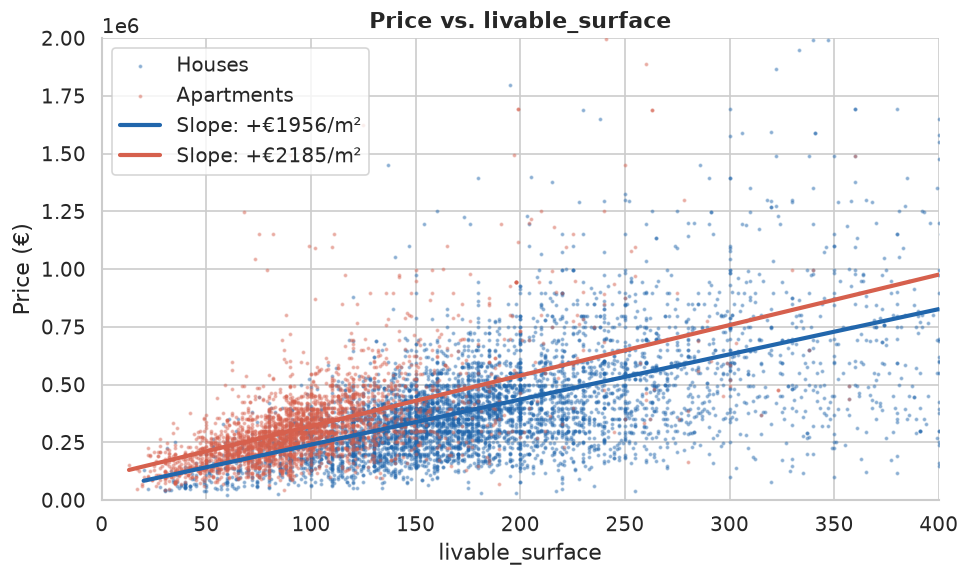

Pearson r = 0.658  (p = 0.00e+00)
→ Moderate positive correlation — livable_surface predicts price but not perfectly.
Spearman r = 0.628  (pval = 0.00e+00)
→ Moderate positive correlation — livable_surface predicts price but not perfectly.


In [12]:

dfscatter = dfs                 # dfs or dfr
variable = 'livable_surface' # 'livable_surface', 'number_of_bedrooms' or 'number_of_bathrooms'

plt.scatter(dfscatter[dfscatter["property_type"]=="House"][variable], \
            dfscatter[dfscatter["property_type"]=="House"]['price'], \
                alpha=0.35, color=BLUE, s=2, label = "Houses")
plt.scatter(dfscatter[dfscatter["property_type"]=="Appartment"][variable], \
            dfscatter[dfscatter["property_type"]=="Appartment"]['price'], \
                alpha=0.35, color=ORANGE, s=2, label = "Apartments")
df_cor = dfscatter[['price',variable,'property_type']].dropna(how='any')
# Add regression line
mh, bh = np.polyfit(df_cor[df_cor["property_type"]=="House"][variable], df_cor[df_cor["property_type"]=="House"]['price'], 1)
x_lineh = np.linspace(df_cor[df_cor["property_type"]=="House"][variable].min(), df_cor[df_cor["property_type"]=="House"][variable].max(), 100)
plt.plot(x_lineh, mh*x_lineh + bh, color=BLUE, lw=2.5, label=f'Slope: +€{mh:.0f}/m²')
ma, ba = np.polyfit(df_cor[df_cor["property_type"]=="Appartment"][variable], df_cor[df_cor["property_type"]=="Appartment"]['price'], 1)
x_linea = np.linspace(df_cor[df_cor["property_type"]=="Appartment"][variable].min(), df_cor[df_cor["property_type"]=="Appartment"][variable].max(), 100)
plt.plot(x_linea, ma*x_linea + ba, color=ORANGE, lw=2.5, label=f'Slope: +€{ma:.0f}/m²')
plt.xlabel(f'{variable}')
plt.xlim((0,400))
plt.ylim((0,2e6))
plt.ylabel('Price (€)')
plt.title(f'Price vs. {variable}')
plt.legend()
plt.show()

r, p = stats.pearsonr(df_cor[variable], df_cor['price'])
print(f"Pearson r = {r:.3f}  (p = {p:.2e})")
print(f"→ Moderate positive correlation — {variable} predicts price but not perfectly.")
spear = stats.spearmanr(df_cor[variable], df_cor['price'])
print(f"Spearman r = {spear.statistic:.3f}  (pval = {spear.pvalue:.2e})")
print(f"→ Moderate positive correlation — {variable} predicts price but not perfectly.")

## 10 What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? (in terms of price per m², average price, and median price)

In [ ]:
df = dfs # dfs or dfr
df_cor = df[["price","livable_surface","postal_code","province"]].dropna(how='any')
df_cor["price_per_surf"] = df_cor["price"]/df_cor["livable_surface"]
df_cor["municipality"] = df_cor["postal_code"]//10 * 10
df_per_muni = df_cor.groupby("municipality")["price_per_surf"].agg(["mean","median"])
municipality_province = df_cor[["municipality","province"]].drop_duplicates()
df_per_muni = df_per_muni.merge(municipality_province,on="municipality")
province_region = {"Brussels":"Brussels","Liège":"Wallonia","Namur":"Wallonia","Hainaut":"Wallonia",\
                   "Luxembourg":"Wallonia","Brabant wallon":"Wallonia","Vlaams brabant":"Flanders",\
                    "Antwerp":"Flanders","Limburg":"Flanders","West vlaanderen":"Flanders","Oost vlaanderen":"Flanders"}
df_per_muni['region'] = df_per_muni['province'].map(province_region)
df_per_muni = df_per_muni.set_index("municipality")
#print(df_per_muni.head())

print(f"Municipality in Belgium with lowest mean price per m² : {df_per_muni["mean"].idxmin()} ({df_per_muni["mean"].min():.0f} €)")
print(f"Municipality in Belgium with lowest median price per m² : {df_per_muni["median"].idxmin()} ({df_per_muni["median"].min():.0f} €)")
print(f"Municipality in Belgium with highest mean price per m² : {df_per_muni["mean"].idxmax()} ({df_per_muni["mean"].max():.0f} €)")
print(f"Municipality in Belgium with highest median price per m² : {df_per_muni["median"].idxmax()} ({df_per_muni["median"].max():.0f} €)")
# 9060 : Zelzate
# 8300 : Knokke
print("-"*20)
print(f"Municipality in Brussels with lowest mean price per m² : {df_per_muni[df_per_muni["province"]=="Brussels"]["mean"].idxmin()} ({df_per_muni[df_per_muni["province"]=="Brussels"]["mean"].min():.0f} €)")
print(f"Municipality in Brussels with lowest median price per m² : {df_per_muni[df_per_muni["province"]=="Brussels"]["median"].idxmin()} ({df_per_muni[df_per_muni["province"]=="Brussels"]["median"].min():.0f} €)")
print(f"Municipality in Brussels with highest mean price per m² : {df_per_muni[df_per_muni["province"]=="Brussels"]["mean"].idxmax()} ({df_per_muni[df_per_muni["province"]=="Brussels"]["mean"].max():.0f} €)")
print(f"Municipality in Brussels with highest median price per m² : {df_per_muni[df_per_muni["province"]=="Brussels"]["median"].idxmax()} ({df_per_muni[df_per_muni["province"]=="Brussels"]["median"].max():.0f} €)")
# 1080 : 
# 1070 : 
# 1150 :
# 1050 : 
print("-"*20)
print(f"Municipality in Wallonia with lowest mean price per m² : {df_per_muni[df_per_muni["region"]=="Wallonia"]["mean"].idxmin()} ({df_per_muni[df_per_muni["region"]=="Wallonia"]["mean"].min():.0f} €)")
print(f"Municipality in Wallonia with lowest median price per m² : {df_per_muni[df_per_muni["region"]=="Wallonia"]["median"].idxmin()} ({df_per_muni[df_per_muni["region"]=="Wallonia"]["median"].min():.0f} €)")
print(f"Municipality in Wallonia with highest mean price per m² : {df_per_muni[df_per_muni["region"]=="Wallonia"]["mean"].idxmax()} ({df_per_muni[df_per_muni["region"]=="Wallonia"]["mean"].max():.0f} €)")
print(f"Municipality in Wallonia with highest median price per m² : {df_per_muni[df_per_muni["region"]=="Wallonia"]["median"].idxmax()} ({df_per_muni[df_per_muni["region"]=="Wallonia"]["median"].max():.0f} €)")
# 4170 : 
# 7370 : 
# 1340 : Lasne
print("-"*20)
print(f"Municipality in Flanders with lowest mean price per m² : {df_per_muni[df_per_muni["region"]=="Flanders"]["mean"].idxmin()} ({df_per_muni[df_per_muni["region"]=="Flanders"]["mean"].min():.0f} €)")
print(f"Municipality in Flanders with lowest median price per m² : {df_per_muni[df_per_muni["region"]=="Flanders"]["median"].idxmin()} ({df_per_muni[df_per_muni["region"]=="Flanders"]["median"].min():.0f} €)")
print(f"Municipality in Flanders with highest mean price per m² : {df_per_muni[df_per_muni["region"]=="Flanders"]["mean"].idxmax()} ({df_per_muni[df_per_muni["region"]=="Flanders"]["mean"].max():.0f} €)")
print(f"Municipality in Flanders with highest median price per m² : {df_per_muni[df_per_muni["region"]=="Flanders"]["median"].idxmax()} ({df_per_muni[df_per_muni["region"]=="Flanders"]["median"].max():.0f} €)")


Municipality in Belgium with lowest mean price per m² : 9060 (625 €)
Municipality in Belgium with lowest median price per m² : 9060 (625 €)
Municipality in Belgium with highest mean price per m² : 8300 (7894 €)
Municipality in Belgium with highest median price per m² : 8300 (6795 €)
--------------------
Municipality in Brussels with lowest mean price per m² : 1080 (2651 €)
Municipality in Brussels with lowest median price per m² : 1070 (2568 €)
Municipality in Brussels with highest mean price per m² : 1150 (4586 €)
Municipality in Brussels with highest median price per m² : 1050 (4426 €)
--------------------
Municipality in Wallonia with lowest mean price per m² : 4170 (949 €)
Municipality in Wallonia with lowest median price per m² : 7370 (783 €)
Municipality in Wallonia with highest mean price per m² : 1340 (3931 €)
Municipality in Wallonia with highest median price per m² : 1340 (3804 €)
--------------------
Municipality in Flanders with lowest mean price per m² : 9060 (625 €)
Munic

## 11 Compute Return On Investment

In [ ]:
df = dfs



🗺️ Module 1 — The Visual Thinking Framework

## 1.1 Choosing the Right Chart

Before you write a single line of plotting code, answer **two questions**:

1. **What is your data type?**
2. **What relationship are you trying to show?**

The table below is your decision guide:

| What you want to show | Data types involved | Best chart(s) |
|-----------------------|---------------------|---------------|
| Distribution of one variable | Numerical | Histogram, KDE, Box, Violin |
| Distribution of one variable | Categorical | Bar (counts), Lollipop |
| Relationship / correlation | Numerical × Numerical | Scatter, Hex bin |
| Relationship | Categorical × Numerical | Box, Violin, Strip |
| Comparison across groups | Categorical × Numerical | Grouped bar, Dot plot |
| Composition (parts of whole) | Categorical + values | Stacked bar, Treemap |
| Trend over time | Date × Numerical | Line chart |
| Multivariate overview | Many numericals | Pair plot, Heatmap |


 **Golden rule:** If you need a legend to explain what the x-axis means, reconsider the chart type.


## 1.2 Data Type Taxonomy
Your statistical analysis and visualization tools will vary depending on the type of data you are working on. It is a CRUCIAL step to avoid mistakes.

| Type | Subtypes & Examples |
| :--- | :--- |
| **Numerical**<br>*(Quantitative)* | • **Continuous:** Salary, temperature, height <br>• **Discrete:** Count of items, number of children |
| **Categorical**<br>*(Qualitative)* | • **Nominal:** Department, country, colour *(no order)* <br>• **Ordinal:** Seniority, rating, education level *(has order)* |

We have provided a quick reference below, using matplotlib. Take a moment to understand the syntax in the code block below.

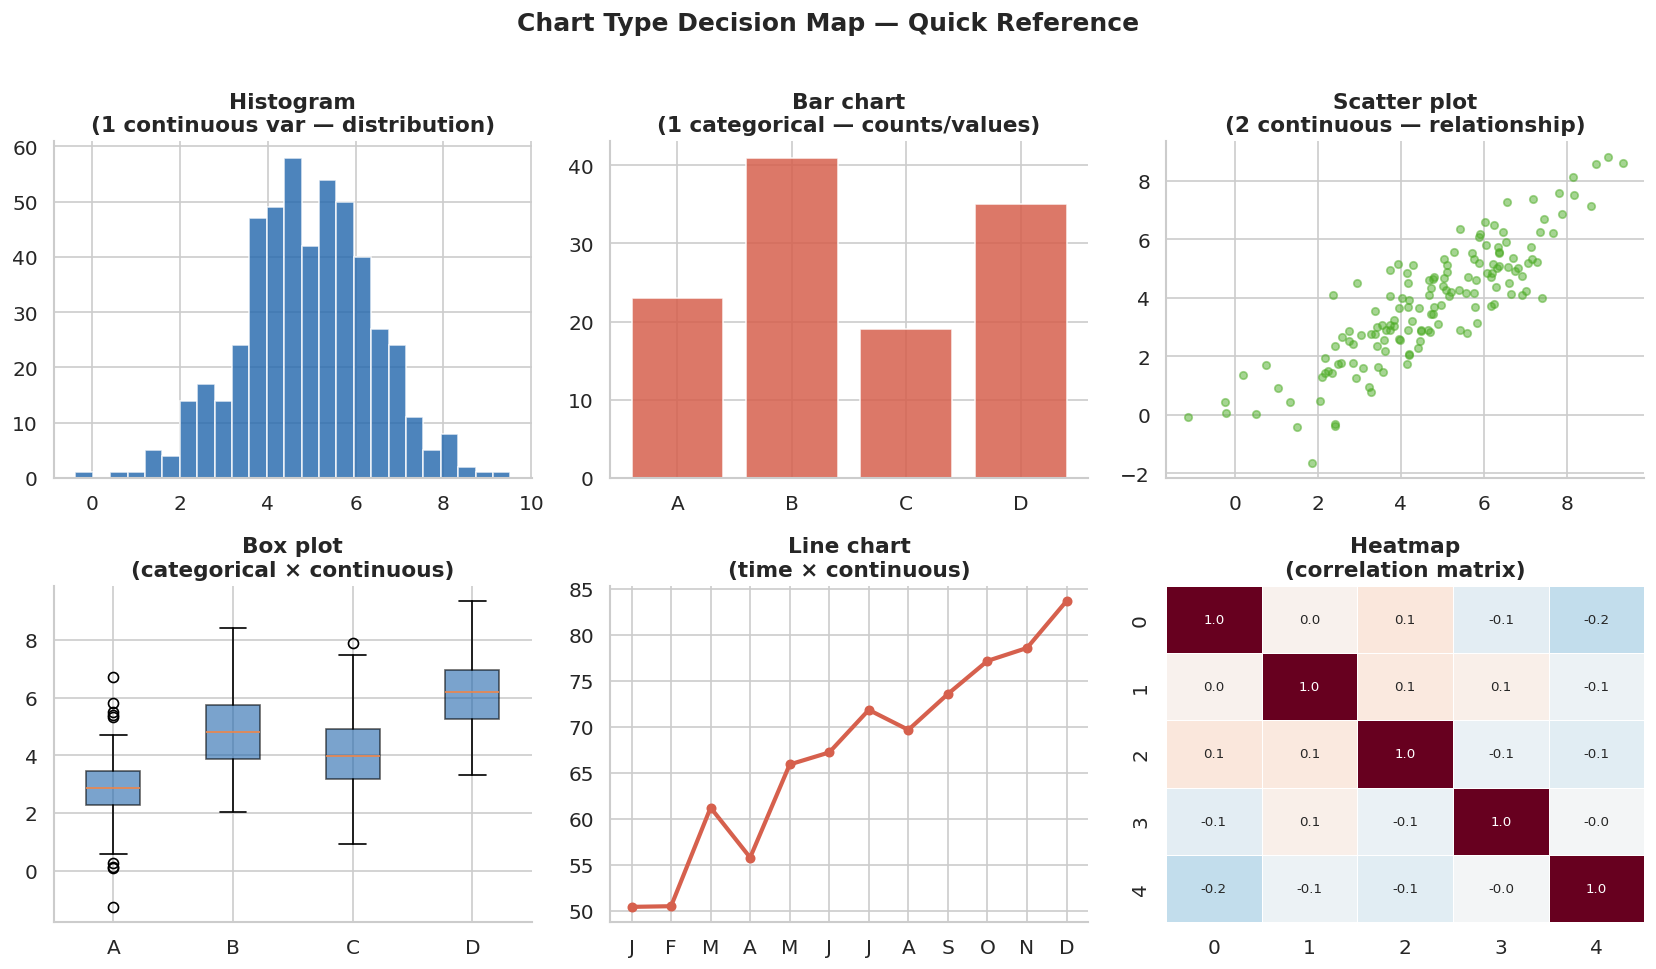

Refer back to this grid whenever you're unsure which chart to pick.


In [3]:
# ── Visual overview of the framework ──────────────────────────────────────

# plt.subplots(rows, cols, figsize=(width, height)) creates a grid of axes we can plot on
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# fig.suptitle() adds a title for the entire figure (not just one subplot)
fig.suptitle('Chart Type Decision Map — Quick Reference', fontsize=15, fontweight='bold', y=1.01)

titles = [
    'Histogram\n(1 continuous var — distribution)',
    'Bar chart\n(1 categorical — counts/values)',
    'Scatter plot\n(2 continuous — relationship)',
    'Box plot\n(categorical × continuous)',
    'Line chart\n(time × continuous)',
    'Heatmap\n(correlation matrix)',
]

# Let's create some example data. 
# linspace(start, end, num_points) generates evenly spaced numbers over a specified interval
x = np.linspace(0, 10, 200)

# 1 Histogram: 
# axes[row, col] selects the specific subplot to plot on
# hist() creates a histogram, bins=25 sets the number of bars, color and alpha control appearance
axes[0,0].hist(np.random.normal(5, 1.5, 500), bins=25, color=BLUE, alpha=0.8, edgecolor='white')
axes[0,0].set_title(titles[0])

# 2 Bar
# bar() creates a bar chart, cats are the categories on x-axis, vals are the heights of the bars
cats = ['A','B','C','D']
vals = [23, 41, 19, 35]
axes[0,1].bar(cats, vals, color=ORANGE, alpha=0.85, edgecolor='white')
axes[0,1].set_title(titles[1])

# 3 Scatter
# scatter() creates a scatter plot, x_s and y_s are the coordinates of the points, color and alpha control appearance, s sets marker size
x_s = np.random.normal(5, 2, 150)
axes[0,2].scatter(x_s, 0.8*x_s + np.random.normal(0,1,150),
                  color=GREEN, alpha=0.5, s=20)
axes[0,2].set_title(titles[2])

# 4 Box
# boxplot() creates a box plot, data_box contains the data for each category, labels specify the category names, patch_artist=True allows customizing the appearance of the boxes
data_box = [np.random.normal(m, 1.2, 100) for m in [3,5,4,6]]
axes[1,0].boxplot(data_box, labels=cats, patch_artist=True,
                  boxprops=dict(facecolor=BLUE, alpha=0.6))
axes[1,0].set_title(titles[3])

# 5 Line
# plot() creates a line chart, t is the x-axis values (e.g. time), the second argument is the y-axis values, color and lw control appearance, marker and ms set the style of the points
t = np.arange(12)
axes[1,1].plot(t, 50 + t*3 + np.random.normal(0,3,12), color=ORANGE, lw=2.5, marker='o', ms=5)
axes[1,1].set_title(titles[4])
axes[1,1].set_xticks(t); axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

# 6 Heatmap
# heatmap() creates a heatmap, corr is the correlation matrix to visualize, cmap sets the color scheme, center=0 makes white represent zero correlation, annot=True adds the correlation values on the cells, fmt='.1f' formats the annotation to 1 decimal place, linewidths adds lines between cells, cbar=False hides the colorbar, annot_kws sets annotation font size
corr = np.corrcoef(np.random.randn(5, 80))
sns.heatmap(corr, ax=axes[1,2], cmap='RdBu_r', center=0, annot=True, fmt='.1f',
            linewidths=0.5, cbar=False, annot_kws={'size': 8})
axes[1,2].set_title(titles[5])

# tight_layout() adjusts spacing to prevent overlap, 
# savefig() saves the figure to a file, 
# show() displays it
plt.tight_layout()
plt.savefig('./tmp/chart_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print("Refer back to this grid whenever you're unsure which chart to pick.")


# 📐 Module 2 — Descriptive Statistics

## 2.1 The Five-Number Summary (and friends)

Every numerical variable can be summarised by:

| Statistic | Tells you | Sensitive to outliers? |
|-----------|-----------|------------------------|
| Mean | Centre of mass | ✅ Yes |
| Median | Middle value (50th percentile) | ❌ No |
| Std dev | Average spread from mean | ✅ Yes |
| IQR (Q3-Q1) | Spread of middle 50% | ❌ No |
| Skewness | Asymmetry of distribution | — |
| Kurtosis | Heaviness of tails | — |

**Rule of thumb:** If mean ≠ median by more than ~10%, your data is skewed. For skewed data, **median is a better summary than mean**.

`pandas` already has implemented many of this metrics for you! For any series, we can use:

- `quantile()`: computes the specified quantiles, here we get Q1 (25%) and Q3 (75%) to calculate the InterQuartile Range.
- `count(), mean(), median(), std(), min(), max(), skew(), kurt()`: compute standard statistical metrics.

The function below provides a summary for each of the numerical columns in our data. You can think of this as a more specific version of the `describe` method in the previous chapter. 

In [4]:
# Compute a professional summary table
def full_summary(series, name=None):
    
    q1, q3 = series.quantile([0.25, 0.75])
    return pd.Series({
        'count':    series.count(),
        'mean':     series.mean(),
        'median':   series.median(),
        'std':      series.std(),
        'IQR':      q3 - q1,
        'min':      series.min(),
        'Q1':       q1,
        'Q3':       q3,
        'max':      series.max(),
        'skewness': series.skew(),
        'kurtosis': series.kurt(),
    }, name=name or series.name)

numerical_cols = ['salary', 'years_exp', 'performance', 'satisfaction', 'remote_pct']
summary = pd.concat([full_summary(df[c]) for c in numerical_cols], axis=1).round(2)
summary


,salary,years_exp,performance,satisfaction,remote_pct
count,400.00,400.00,400.00,400.00,400.00
mean,75325.25,6.45,3.31,3.21,47.34
median,72150.00,6.20,3.30,3.20,47.00
std,24231.36,3.41,0.62,0.79,22.25
IQR,35925.00,5.83,0.80,1.10,35.00
min,36100.00,1.00,1.30,1.30,2.00
Q1,54575.00,3.60,2.90,2.70,30.00
Q3,90500.00,9.43,3.70,3.80,65.00
max,172800.00,16.20,5.00,5.00,100.00
skewness,0.64,0.37,-0.12,0.08,0.18


In [5]:
# Interpret the skewness of salary
sk = df['salary'].skew()
print(f"Salary skewness: {sk:.2f}")
print(f"Mean salary:   €{df['salary'].mean():,.0f}")
print(f"Median salary: €{df['salary'].median():,.0f}")
print(f"Difference: {abs(df['salary'].mean() - df['salary'].median()) / df['salary'].median() * 100:.1f}%")
print()
if sk > 0.5:
    print("→ Right-skewed: a few high earners pull the mean up.")
    print("  For salary reporting, median is more representative.")
elif sk < -0.5:
    print("→ Left-skewed: a few low earners pull the mean down.")
else:
    print("→ Roughly symmetric: mean ≈ median.")


Salary skewness: 0.64
Mean salary:   €75,325
Median salary: €72,150
Difference: 4.4%

→ Right-skewed: a few high earners pull the mean up.
  For salary reporting, median is more representative.


## ✏️ Exercise 2.1
1. For `performance` scores, is the mean or median a better measure of centre? Justify with numbers.
2. Which column has the highest coefficient of variation (CV = std/mean × 100%)?
   CV measures relative variability — useful for comparing columns with different units.


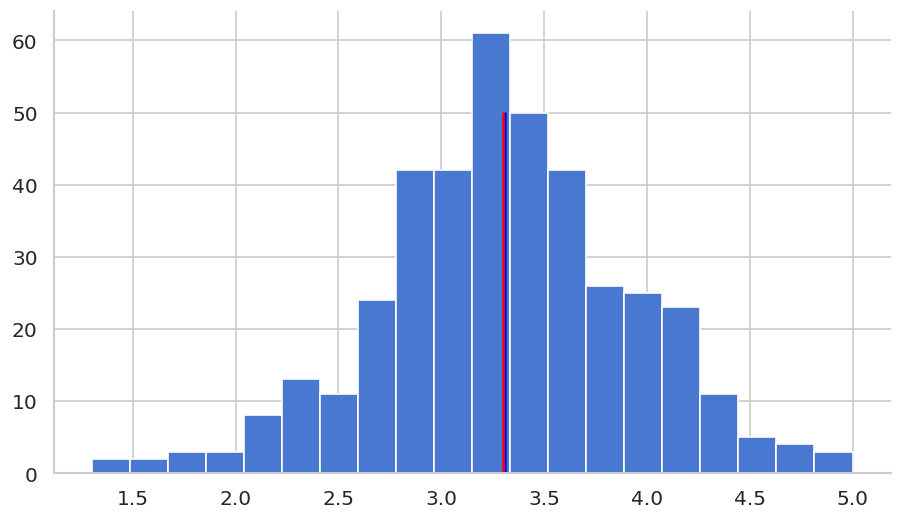

In [10]:
# YOUR CODE HERE
#1. 
plt.hist(df['performance'],bins=20)
plt.plot([df['performance'].mean(),df['performance'].mean()],[0,50],color="blue")
plt.plot([df['performance'].median(),df['performance'].median()],[0,50],color="red")
plt.show()

In [8]:
# 💡 SOLUTION
print("=== Performance: mean vs median ===")
print(f"  Mean:     {df['performance'].mean():.3f}")
print(f"  Median:   {df['performance'].median():.3f}")
print(f"  Skewness: {df['performance'].skew():.3f}")
print("  → Low skewness; mean and median are similar. Either is fine.")

print("\n=== Coefficient of Variation ===")
cv = (df[numerical_cols].std() / df[numerical_cols].mean() * 100).round(1)
cv_sorted = cv.sort_values(ascending=False)
for col, val in cv_sorted.items():
    print(f"  {col:15s}: {val:.1f}%")
print(f"\nHighest CV: {cv_sorted.idxmax()} — most variable relative to its mean")


=== Performance: mean vs median ===
  Mean:     3.312
  Median:   3.300
  Skewness: -0.124
  → Low skewness; mean and median are similar. Either is fine.

=== Coefficient of Variation ===
  years_exp      : 52.9%
  remote_pct     : 47.0%
  salary         : 32.2%
  satisfaction   : 24.7%
  performance    : 18.7%

Highest CV: years_exp — most variable relative to its mean


# 📈 Module 3 — Distributions
## 3.1 Histogram vs KDE vs ECDF

Three ways to see the shape of one numerical variable:

| Chart | Best for | Watch out for |
|-------|----------|---------------|
| Histogram | Seeing frequency counts | Bin width strongly affects appearance |
| KDE (smooth density) | Comparing distributions | Can imply values beyond data range |
| ECDF | Reading percentiles directly | Less intuitive at first |

### KDE (Kernel density estimation)

Applies the kernel smoothing for probability density estimation. The bandwidth of the Gaussian kernel is automatically computed.

wikipedia : [https://en.wikipedia.org/wiki/Kernel_density_estimation]

pandas doc : [https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.kde.html]

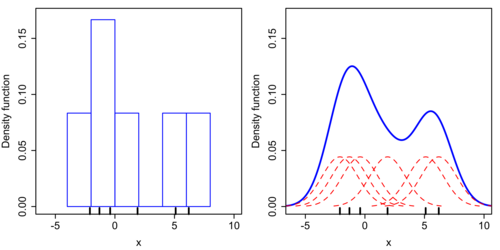

### ECDF (empirical cumulative distribution function)

Step function that jumps up by 1/n at each of the n data points.

wikipedia : [https://en.wikipedia.org/wiki/Empirical_distribution_function]


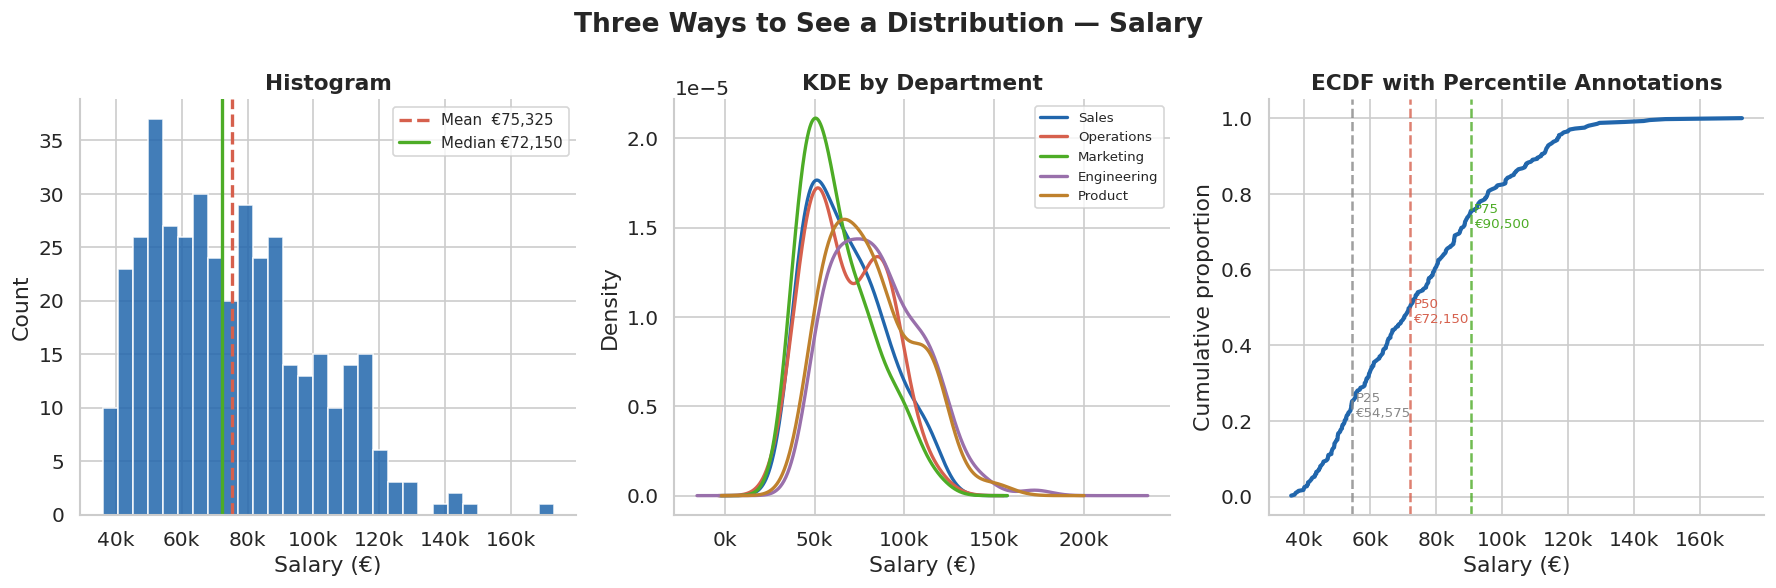

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Three Ways to See a Distribution — Salary', fontweight='bold')

sal = df['salary']

# ── 1. Histogram with rug ──────────────────────────────────────────────────
axes[0].hist(sal, bins=30, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(sal.mean(),   color=ORANGE, lw=2, ls='--', label=f'Mean  €{sal.mean():,.0f}')
axes[0].axvline(sal.median(), color=GREEN,  lw=2, ls='-',  label=f'Median €{sal.median():,.0f}')
axes[0].set_xlabel('Salary (€)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# ── 2. KDE by department ───────────────────────────────────────────────────
for i, dept in enumerate(df['department'].unique()):
    subset = df.loc[df['department'] == dept, 'salary']
    subset.plot.kde(ax=axes[1], label=dept, color=PALETTE[i], lw=2)
axes[1].set_xlabel('Salary (€)')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE by Department')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# ── 3. ECDF ────────────────────────────────────────────────────────────────
sorted_sal = np.sort(sal)
ecdf = np.arange(1, len(sorted_sal)+1) / len(sorted_sal)
axes[2].plot(sorted_sal, ecdf, color=BLUE, lw=2.5)
# Annotate percentiles
for pct, col in [(25, GREY), (50, ORANGE), (75, GREEN)]:
    val = np.percentile(sorted_sal, pct)
    axes[2].axvline(val, color=col, lw=1.5, ls='--', alpha=0.8)
    axes[2].text(val+1000, pct/100 - 0.04, f'P{pct}\n€{val:,.0f}',
                 fontsize=8, color=col)
axes[2].set_xlabel('Salary (€)')
axes[2].set_ylabel('Cumulative proportion')
axes[2].set_title('ECDF with Percentile Annotations')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()


## 3.2 Box Plot vs Violin Plot

Both show distribution + outliers, but violin adds **density shape**.
Choose box plot for clean comparisons; violin when the shape matters.


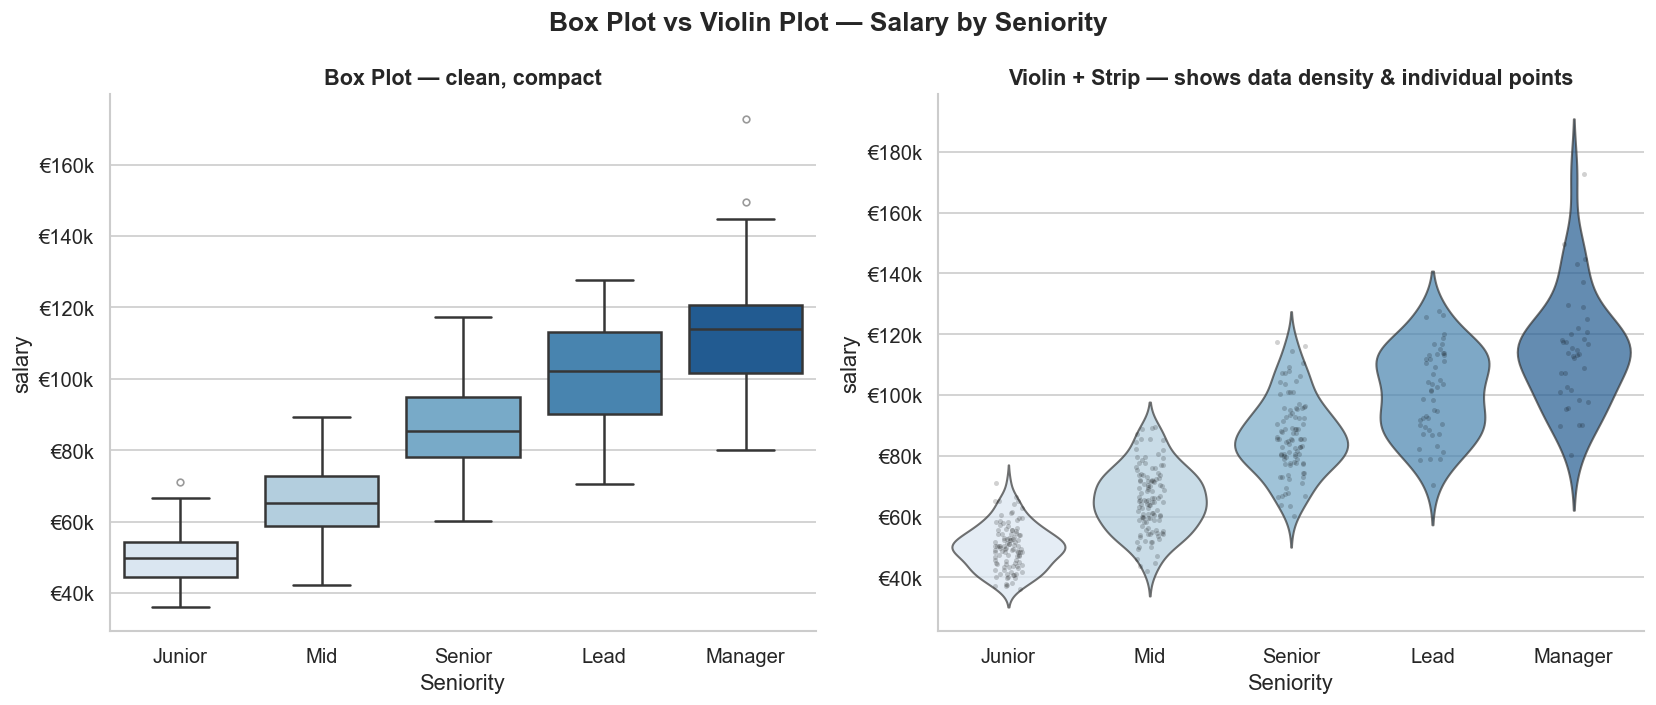

Key insight: Senior engineers have high salary variance —
a wide band in the violin that the box plot masks.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Box Plot vs Violin Plot — Salary by Seniority', fontweight='bold')

order = ['Junior','Mid','Senior','Lead','Manager']

# ── Box plot ──────────────────────────────────────────────────────────────
sns.boxplot(data=df, x='seniority', y='salary', order=order,
            palette='Blues', ax=axes[0], linewidth=1.5,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Box Plot — clean, compact')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
axes[0].set_xlabel('Seniority')

# ── Violin + strip ────────────────────────────────────────────────────────
sns.violinplot(data=df, x='seniority', y='salary', order=order,
               palette='Blues', ax=axes[1], inner=None, alpha=0.7)
sns.stripplot(data=df, x='seniority', y='salary', order=order,
              color='black', alpha=0.18, size=3, ax=axes[1], jitter=True)
axes[1].set_title('Violin + Strip — shows data density & individual points')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
axes[1].set_xlabel('Seniority')

plt.tight_layout()
plt.show()
print("Key insight: Senior engineers have high salary variance —")
print("a wide band in the violin that the box plot masks.")


## ✏️ Exercise 3.1
Plot the distribution of `satisfaction` scores split by `left_company` (True/False).

Use a **violin + strip plot** and interpret: do employees who left have lower satisfaction?
Add mean lines to make the comparison precise.


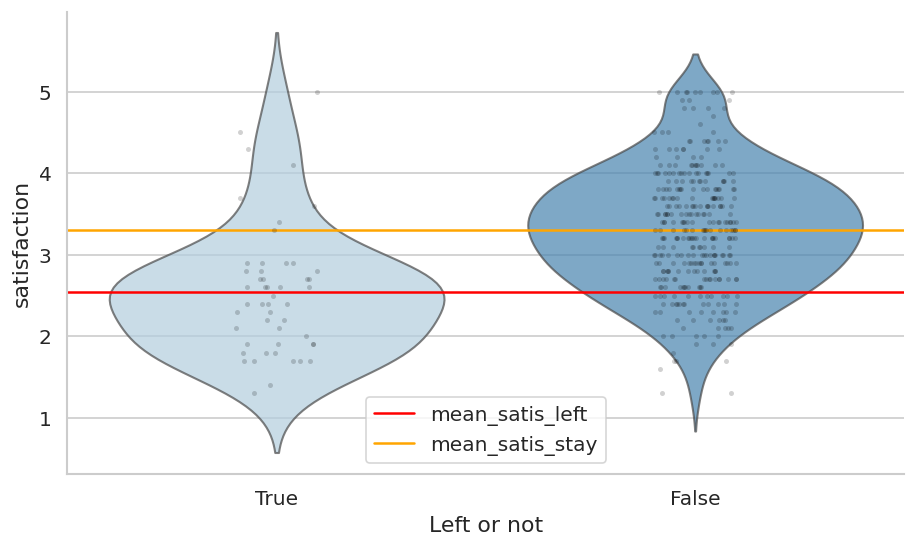

In [ ]:
# YOUR CODE HERE
left_order = ['True','False']
sns.violinplot(data=df, x='left_company', y='satisfaction', order=left_order,
               palette='Blues', inner=None, alpha=0.7)
sns.stripplot(data=df, x='left_company', y='satisfaction', order=left_order,
              color='black', alpha=0.18, size=3, jitter=True)
plt.xlabel('Left or not')
plt.axhline(df[df['left_company']==True]['satisfaction'].mean(),label="mean_satis_left",color="red")
plt.axhline(df[df['left_company']==False]['satisfaction'].mean(),label="mean_satis_stay", color="orange")
plt.legend()
plt.show()



# 🔗 Module 4 — Relationships & Correlation

## 4.1 Scatter Plots — the Workhorse of Exploratory Analysis

A scatter plot answers: **Do two variables move together?**

Encode extra dimensions with: `color` (categorical), `size` (3rd numerical), `marker` (4th categorical).


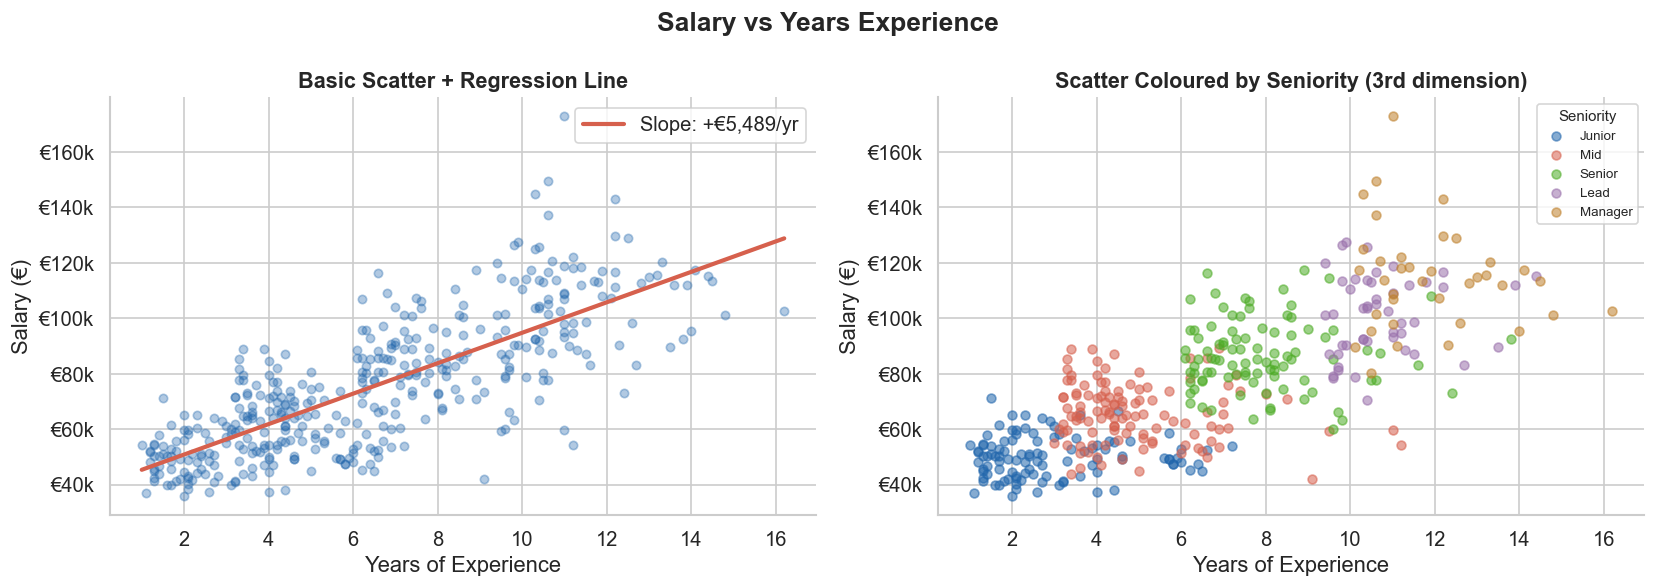

Pearson r = 0.773  (p = 9.32e-81)
→ Moderate positive correlation — experience predicts salary but not perfectly.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salary vs Years Experience', fontweight='bold')

# ── Basic scatter ──────────────────────────────────────────────────────────
axes[0].scatter(df['years_exp'], df['salary'], alpha=0.35, color=BLUE, s=25)
# Add regression line
m, b = np.polyfit(df['years_exp'], df['salary'], 1)
x_line = np.linspace(df['years_exp'].min(), df['years_exp'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color=ORANGE, lw=2.5, label=f'Slope: +€{m:,.0f}/yr')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary (€)')
axes[0].set_title('Basic Scatter + Regression Line')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))

# ── Coloured by seniority ──────────────────────────────────────────────────
seniority_order = ['Junior','Mid','Senior','Lead','Manager']
seniority_colors = dict(zip(seniority_order, PALETTE))
for sen in seniority_order:
    mask = df['seniority'] == sen
    axes[1].scatter(df.loc[mask,'years_exp'], df.loc[mask,'salary'],
                    color=seniority_colors[sen], alpha=0.55, s=28, label=sen)
axes[1].set_xlabel('Years of Experience')
axes[1].set_ylabel('Salary (€)')
axes[1].set_title('Scatter Coloured by Seniority (3rd dimension)')
axes[1].legend(title='Seniority', fontsize=8, title_fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))

plt.tight_layout()
plt.show()
r, p = stats.pearsonr(df['years_exp'], df['salary'])
print(f"Pearson r = {r:.3f}  (p = {p:.2e})")
print("→ Moderate positive correlation — experience predicts salary but not perfectly.")


## 4.2 Correlation Matrix — Overview of All Relationships

Pearson correlation coefficient **r** ranges from -1 to +1:
- **r > 0.7** — strong positive
- **0.3 < r < 0.7** — moderate
- **|r| < 0.3** — weak
- **r < -0.3** — moderate negative

> ⚠️ Correlation ≠ causation. Always check the scatter before trusting a number.


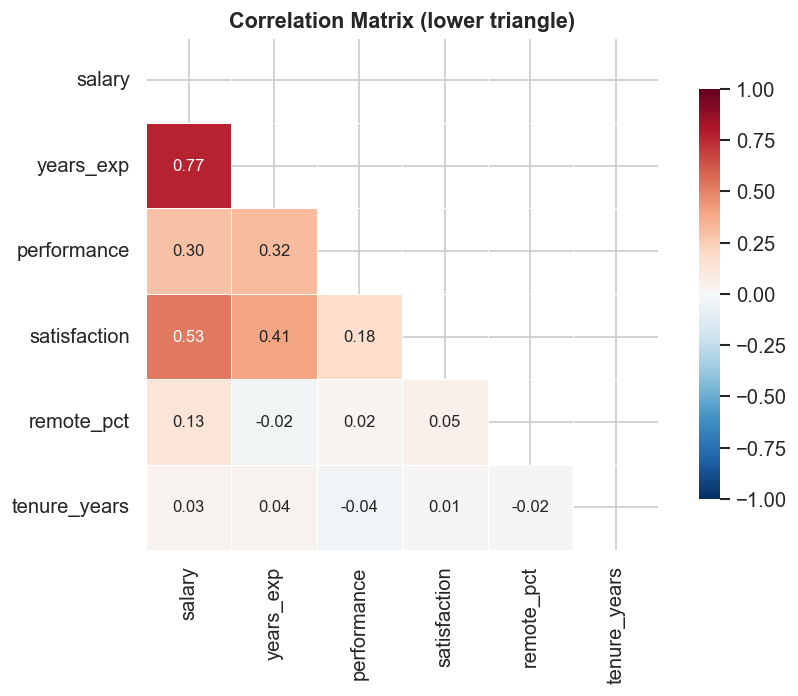

Top 5 correlations:
        var1      var2        r
   years_exp    salary 0.773258
satisfaction    salary 0.530763
satisfaction years_exp 0.405988
 performance years_exp 0.317061
 performance    salary 0.295483


In [19]:
numerical = df[['salary','years_exp','performance','satisfaction','remote_pct','tenure_years']]
corr = numerical.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

ax.set_title('Correlation Matrix (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.show()

# Surface the strongest correlations
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), -1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
    .head(5)
    .rename('r')
    .reset_index()
    .rename(columns={'level_0':'var1','level_1':'var2'})
)
print("Top 5 correlations:")
print(corr_pairs.to_string(index=False))


## 4.3 Pair Plot — All Relationships at Once


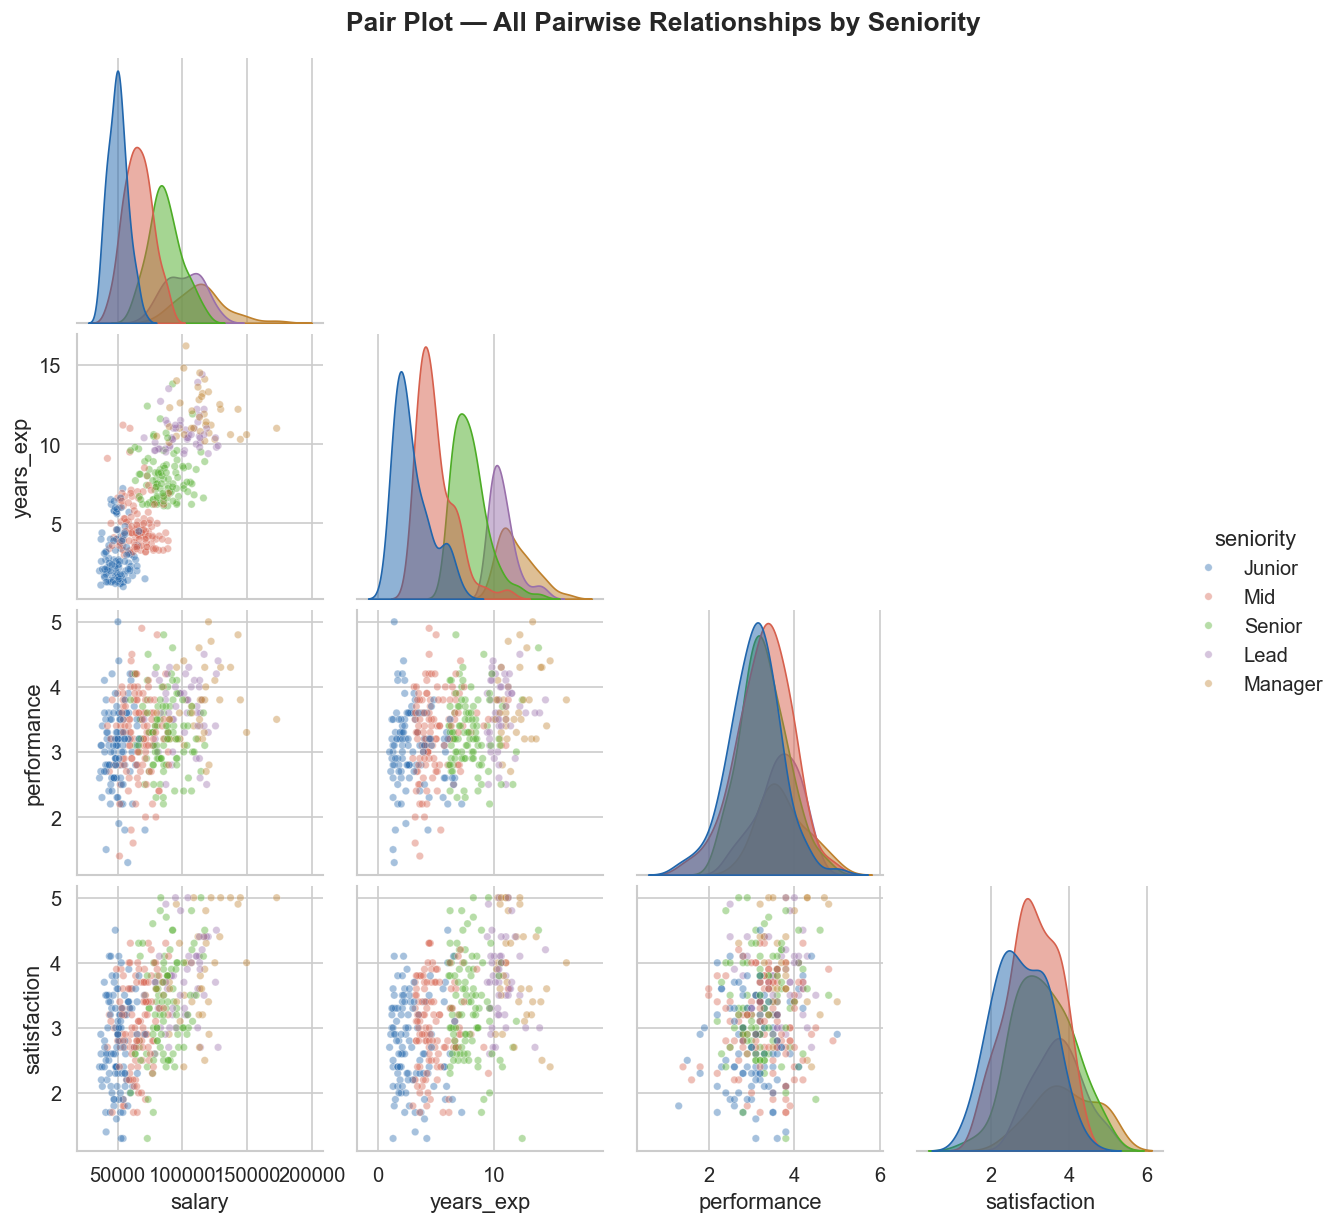

In [20]:
# Pair plot for a subset (all-vs-all would be too busy)
pair_df = df[['salary','years_exp','performance','satisfaction','seniority']].copy()

g = sns.pairplot(
    pair_df,
    hue='seniority',
    hue_order=['Junior','Mid','Senior','Lead','Manager'],
    palette=dict(zip(['Junior','Mid','Senior','Lead','Manager'], PALETTE)),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kws={'fill': True, 'alpha': 0.5},
    corner=True   # only lower triangle — cleaner
)
g.fig.suptitle('Pair Plot — All Pairwise Relationships by Seniority',
               y=1.02, fontweight='bold')
plt.show()


## ✏️ Exercise 4.1
Is there a relationship between `remote_pct` and `satisfaction`?

1. Plot a scatter with a regression line and compute Pearson r.
2. Colour the points by `department`.
3. Interpret: does working remotely correlate with higher satisfaction?


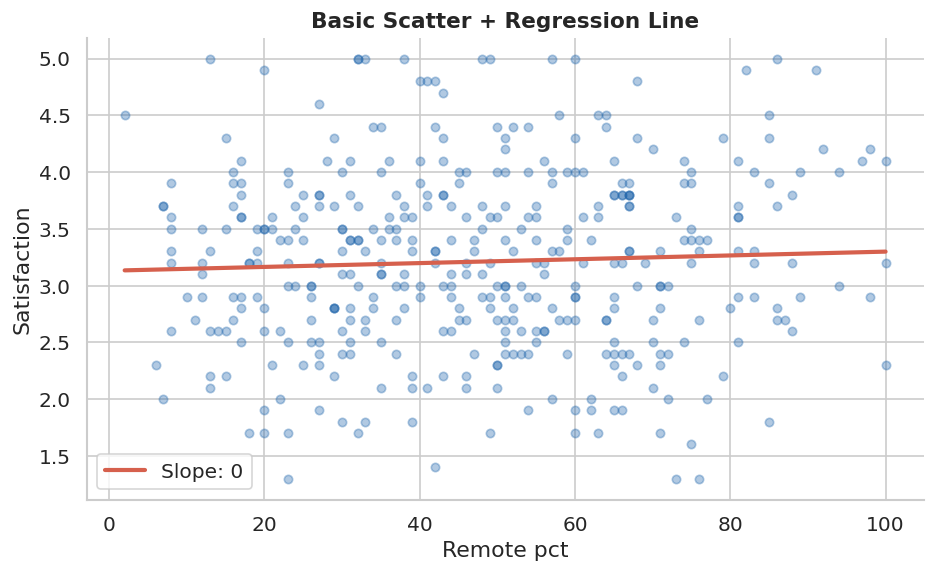

Pearson r = 0.047  (p = 3.45e-01)
→ Moderate positive correlation — experience predicts salary but not perfectly.


In [ ]:
# YOUR CODE HERE
plt.scatter(df['remote_pct'], df['satisfaction'], alpha=0.35, color=BLUE, s=25)
a, b = np.polyfit(df['remote_pct'], df['satisfaction'], 1)
x_line = np.linspace(df['remote_pct'].min(), df['remote_pct'].max(), 100)
plt.plot(x_line, a*x_line + b, color=ORANGE, lw=2.5, label=f'Slope: {a:,.0f}')
plt.xlabel('Remote pct')
plt.ylabel('Satisfaction')
plt.title('Basic Scatter + Regression Line')
plt.legend()
plt.show()

r, p = stats.pearsonr(df['remote_pct'], df['satisfaction'])
print(f"Pearson r = {r:.3f}  (p = {p:.2e})")
print("→ Weak positive correlation — remote pct does not predict satisfaction.")

# 📊 Module 5 — Comparisons Across Groups

## 5.1 Bar Charts — When to Use & When to Avoid

Use bar charts for **comparing values across categories**.

Common mistakes:
- ❌ Using 3D bars (distorts perception)
- ❌ Not starting the y-axis at zero (misleads magnitude)
- ❌ Too many bars — use a dot/lollipop plot above ~10 categories
- ✅ Sort bars by value unless categories have a natural order


    department          mean   median           std
0  Engineering  84608.843537  81700.0  24509.044808
1      Product  81374.193548  76200.0  23757.386672
2        Sales  67729.545455  65050.0  21326.273037
3   Operations  68257.894737  63550.0  20804.880295
4    Marketing  62975.384615  59000.0  19659.420696


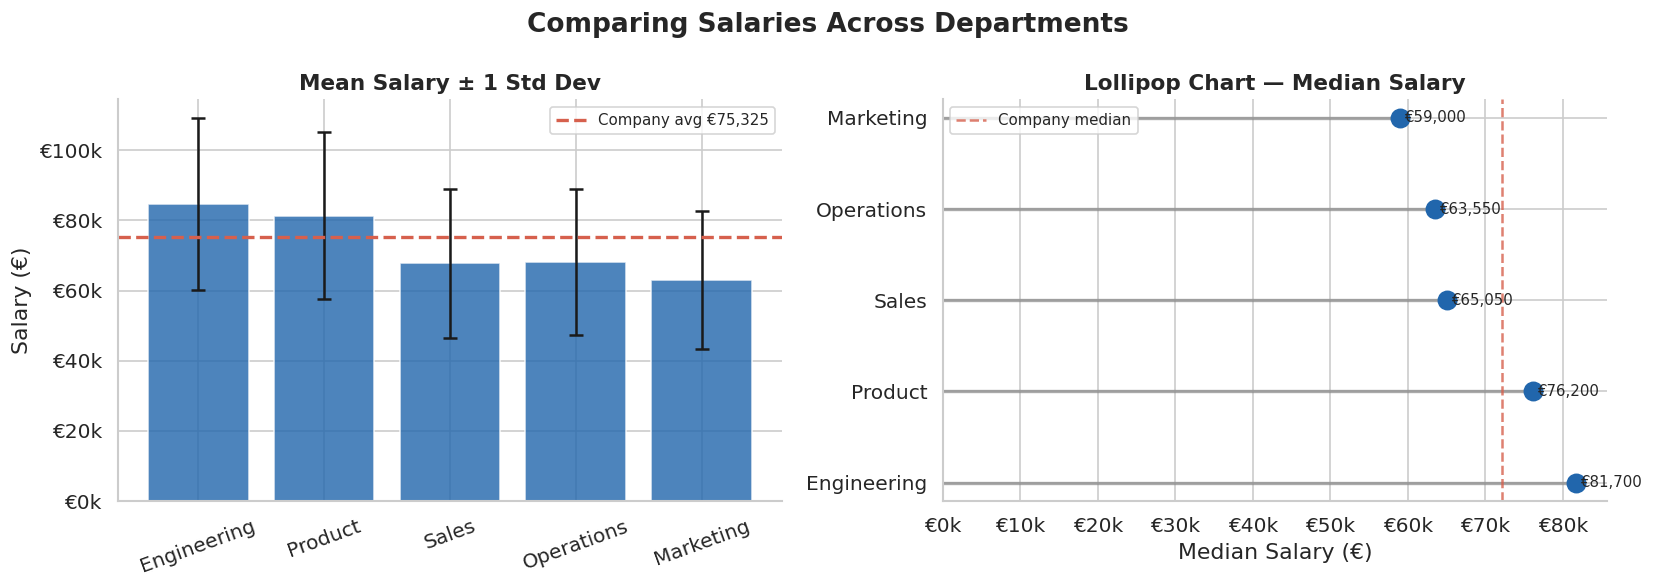

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparing Salaries Across Departments', fontweight='bold')

dept_salary = (
    df.groupby('department')['salary']
    .agg(['mean','median','std'])
    .sort_values('median', ascending=False)
    .reset_index()
)
print(dept_salary)

# ── Bar chart with error bars ──────────────────────────────────────────────
bars = axes[0].bar(dept_salary['department'], dept_salary['mean'],
                   yerr=dept_salary['std'], capsize=4,
                   color=BLUE, alpha=0.8, edgecolor='white',
                   error_kw=dict(lw=1.5, color=GREY, capthick=1.5))
axes[0].axhline(df['salary'].mean(), color=ORANGE, lw=2, ls='--',
                label=f"Company avg €{df['salary'].mean():,.0f}")
axes[0].set_ylabel('Salary (€)')
axes[0].set_title('Mean Salary ± 1 Std Dev')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
axes[0].tick_params(axis='x', rotation=20)

# ── Lollipop chart (better for many categories) ────────────────────────────
axes[1].hlines(dept_salary['department'], 0, dept_salary['median'],
               color=GREY, lw=2, alpha=0.7)
axes[1].scatter(dept_salary['median'], dept_salary['department'],
                color=BLUE, s=120, zorder=3)
for _, row in dept_salary.iterrows():
    axes[1].text(row['median'] + 500, row['department'],
                 f"€{row['median']:,.0f}", va='center', fontsize=9)
axes[1].axvline(df['salary'].median(), color=ORANGE, lw=1.5, ls='--', alpha=0.8,
                label=f"Company median")
axes[1].set_xlabel('Median Salary (€)')
axes[1].set_title('Lollipop Chart — Median Salary')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()


## 5.2 Grouped & Stacked Bar Charts

Use for comparing a metric across **two categorical dimensions** simultaneously.


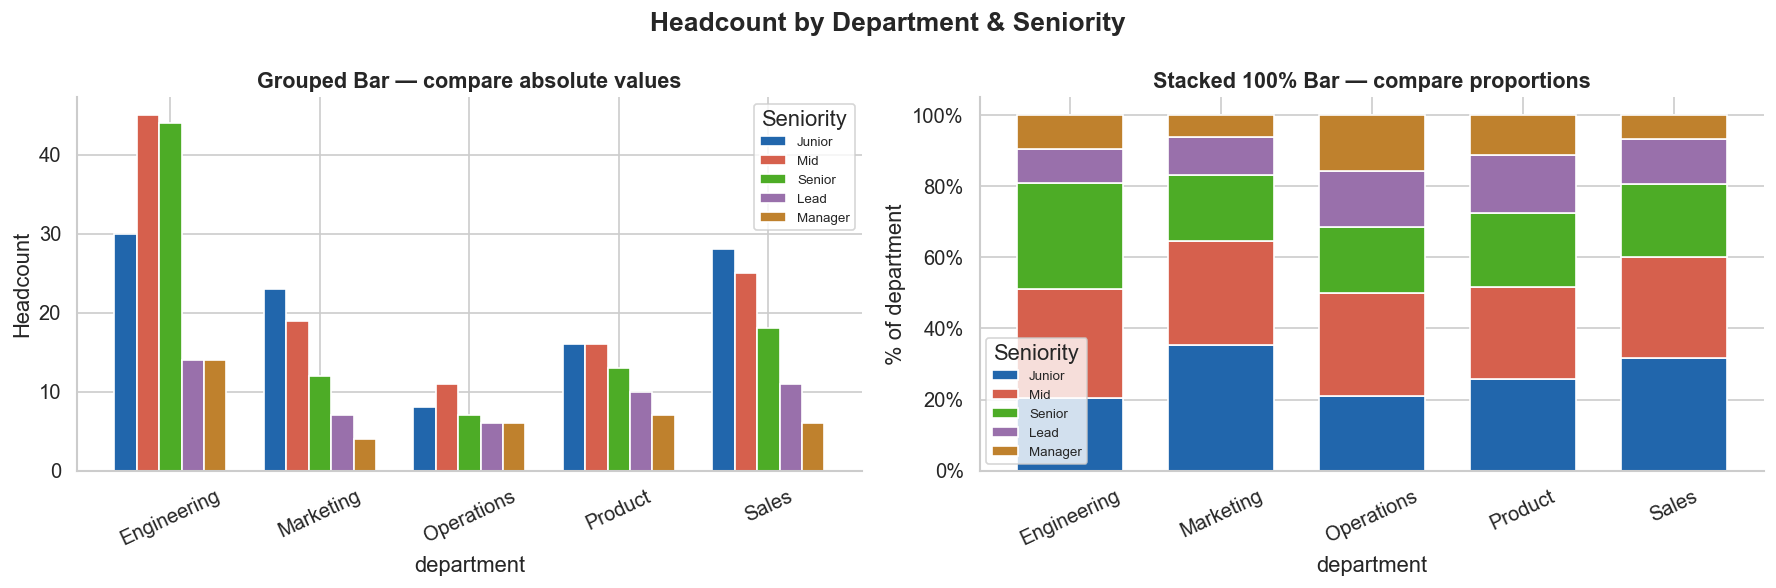

Engineering has proportionally more Seniors & Leads. Sales skews Junior/Mid.


In [22]:
# Headcount by department and seniority
headcount = (
    df.groupby(['department', 'seniority'], observed=True)
    .size()
    .reset_index(name='count')
    .pivot(index='department', columns='seniority', values='count')
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Headcount by Department & Seniority', fontweight='bold')

seniority_order = ['Junior','Mid','Senior','Lead','Manager']
headcount = headcount[seniority_order]

# ── Grouped bar ────────────────────────────────────────────────────────────
headcount.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white',
               width=0.75, rot=25)
axes[0].set_title('Grouped Bar — compare absolute values')
axes[0].set_ylabel('Headcount')
axes[0].legend(title='Seniority', fontsize=8)

# ── Stacked bar (% normalised) ─────────────────────────────────────────────
headcount_pct = headcount.div(headcount.sum(axis=1), axis=0) * 100
headcount_pct.plot(kind='bar', stacked=True, ax=axes[1], color=PALETTE,
                   edgecolor='white', width=0.7, rot=25)
axes[1].set_title('Stacked 100% Bar — compare proportions')
axes[1].set_ylabel('% of department')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(title='Seniority', fontsize=8)

plt.tight_layout()
plt.show()
print("Engineering has proportionally more Seniors & Leads. Sales skews Junior/Mid.")


## ✏️ Exercise 5.1
Create a **horizontal bar chart** showing the **attrition rate** (% who left) per department, sorted highest to lowest.
Add a vertical reference line for the company-wide attrition rate.


    department  count  sum      rate
0      Product     62    4  0.064516
1  Engineering    147   16  0.108844
2   Operations     38    5  0.131579
3    Marketing     65   10  0.153846
4        Sales     88   15  0.170455


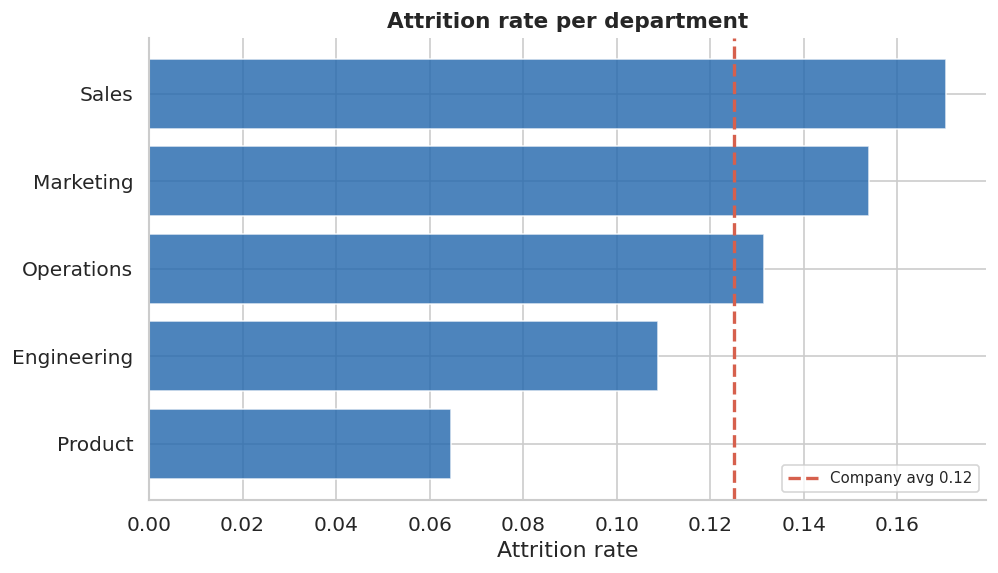

In [36]:
# YOUR CODE HERE
attrition = (
    df.groupby('department', observed=True)['left_company']
    .agg(['count','sum'])
    .assign(
        rate=lambda x:(x['sum']/x['count'])
    )
    .sort_values('rate', ascending=True)
    .reset_index()
)
print(attrition)

bars = plt.barh(attrition['department'], attrition['rate'],
                   capsize=4,
                   color=BLUE, alpha=0.8, edgecolor='white')
comp_attrition_rate = attrition['sum'].sum()/attrition['count'].sum()
plt.axvline(comp_attrition_rate, color=ORANGE, lw=2, ls='--',
                label=f"Company avg {comp_attrition_rate:.02f}")
plt.xlabel('Attrition rate')
plt.title('Attrition rate per department')
plt.legend(fontsize=9)
plt.show()


# Module 6 — Composition (Parts of a Whole)
## 6.1 When Is a Pie Chart OK?

**Use a pie chart only when:**
1. You have ≤5 categories
2. You want to show that one part dominates (~50%+)
3. Exact values don't matter (use bar if they do)

Otherwise: use a **bar chart** — humans are terrible at comparing angles.


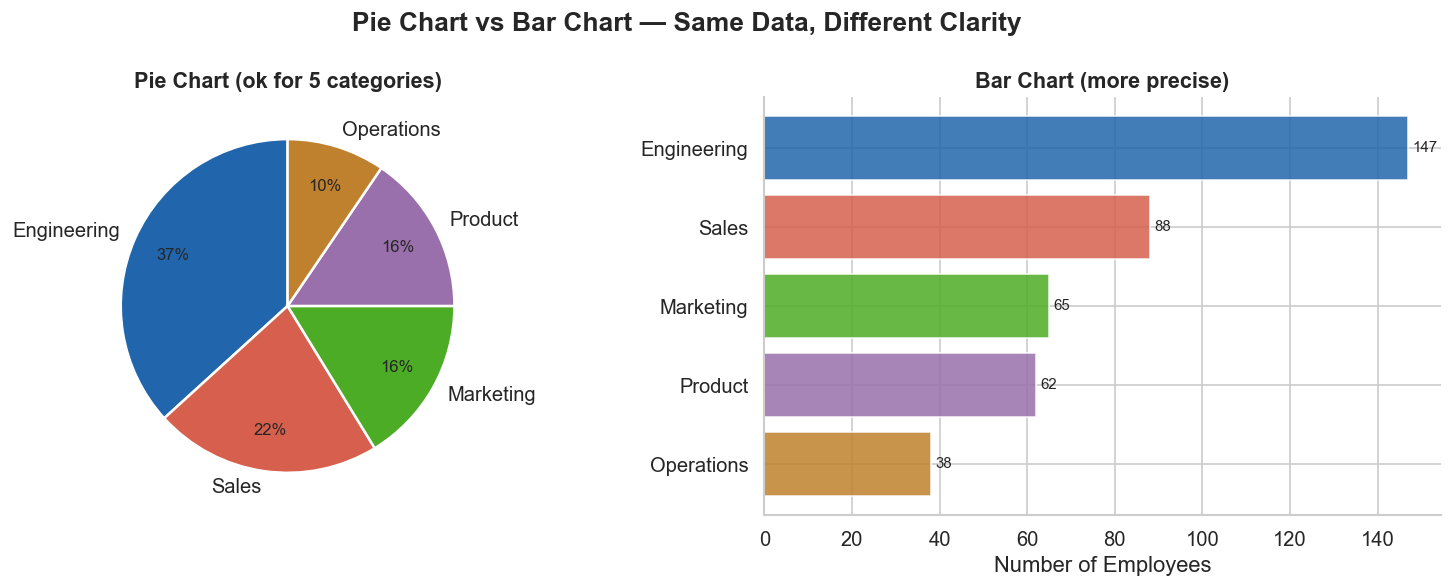

In [23]:
dept_counts = df['department'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pie Chart vs Bar Chart — Same Data, Different Clarity', fontweight='bold')

# ── Pie chart (defensible here: 5 slices, clear majority) ──────────────────
wedges, texts, autotexts = axes[0].pie(
    dept_counts.values,
    labels=dept_counts.index,
    autopct='%1.0f%%',
    colors=PALETTE,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts: t.set_fontsize(10)
axes[0].set_title('Pie Chart (ok for 5 categories)')

# ── Bar chart (more precise comparison) ───────────────────────────────────
axes[1].barh(dept_counts.index[::-1], dept_counts.values[::-1],
             color=PALETTE[::-1], alpha=0.85, edgecolor='white')
for i, (dept, val) in enumerate(zip(dept_counts.index[::-1], dept_counts.values[::-1])):
    axes[1].text(val + 1, i, str(val), va='center', fontsize=9)
axes[1].set_xlabel('Number of Employees')
axes[1].set_title('Bar Chart (more precise)')

plt.tight_layout()
plt.show()


## 6.2 Waffle Chart Alternative (using matplotlib)
A waffle chart is more readable than pie for showing proportions.


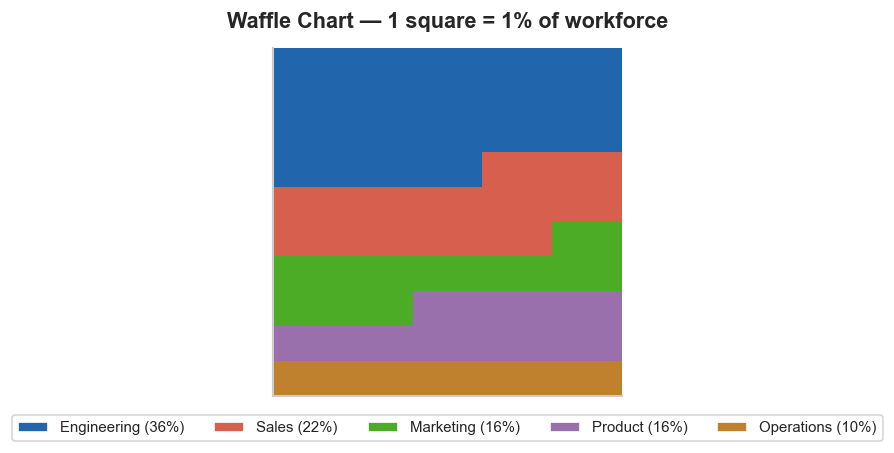

In [24]:
# Waffle-style chart using imshow
fig, ax = plt.subplots(figsize=(10, 4))

# Create a 10x10 grid = 100 squares ≈ 100%
dept_pct = (dept_counts / dept_counts.sum() * 100).round(0).astype(int)
# Adjust to sum to 100
diff = 100 - dept_pct.sum()
dept_pct.iloc[0] += diff

grid = []
for dept, pct in dept_pct.items():
    grid.extend([list(dept_counts.index).index(dept)] * pct)
grid = np.array(grid[:100]).reshape(10, 10)

cmap = plt.cm.colors.ListedColormap(PALETTE[:len(dept_counts)])
im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=len(dept_counts)-1, aspect='equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Waffle Chart — 1 square = 1% of workforce', fontweight='bold', pad=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[i], label=f'{dept} ({pct}%)')
                   for i, (dept, pct) in enumerate(dept_pct.items())]
ax.legend(handles=legend_elements, loc='lower center', ncol=5,
          bbox_to_anchor=(0.5, -0.15), fontsize=9)
plt.tight_layout()
plt.show()


# Module 7 — Trends Over Time
## 7.1 Line Charts — The Standard for Time Series

Rules for good time series charts:
- Line charts for **continuous change** (stock prices, sales)
- Bar charts for **discrete periods** (monthly revenue, quarterly counts)
- Never connect points across **gaps** in data without indicating the gap


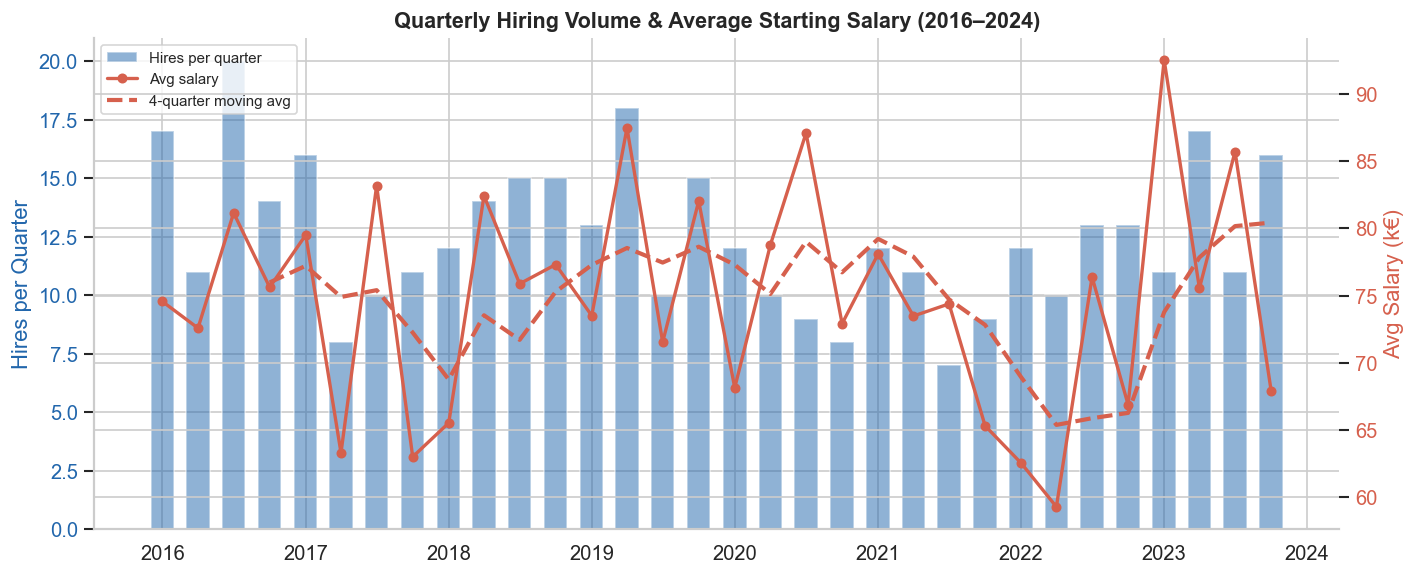

In [25]:
# Generate monthly hiring & attrition data
monthly_hires = (
    df.groupby(df['hire_date'].dt.to_period('Q'))
    .agg(hired=('employee_id','count'),
         avg_salary=('salary','mean'))
    .reset_index()
)
monthly_hires['hire_date'] = monthly_hires['hire_date'].dt.to_timestamp()
monthly_hires['rolling_4q_salary'] = monthly_hires['avg_salary'].rolling(4).mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()  # dual y-axis

# Bars for headcount
ax1.bar(monthly_hires['hire_date'], monthly_hires['hired'],
        width=60, color=BLUE, alpha=0.5, label='Hires per quarter')
ax1.set_ylabel('Hires per Quarter', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)

# Line for average salary
ax2.plot(monthly_hires['hire_date'], monthly_hires['avg_salary']/1000,
         color=ORANGE, lw=2, marker='o', ms=5, label='Avg salary')
ax2.plot(monthly_hires['hire_date'], monthly_hires['rolling_4q_salary']/1000,
         color=ORANGE, lw=2.5, ls='--', label='4-quarter moving avg')
ax2.set_ylabel('Avg Salary (k€)', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')

ax1.set_title('Quarterly Hiring Volume & Average Starting Salary (2016–2024)',
              fontweight='bold')
plt.tight_layout()
plt.show()


## 7.2 Annotations — Making Charts Tell a Story

A chart without context forces the reader to do the analyst's job.
Annotate inflection points, outliers, and key events.


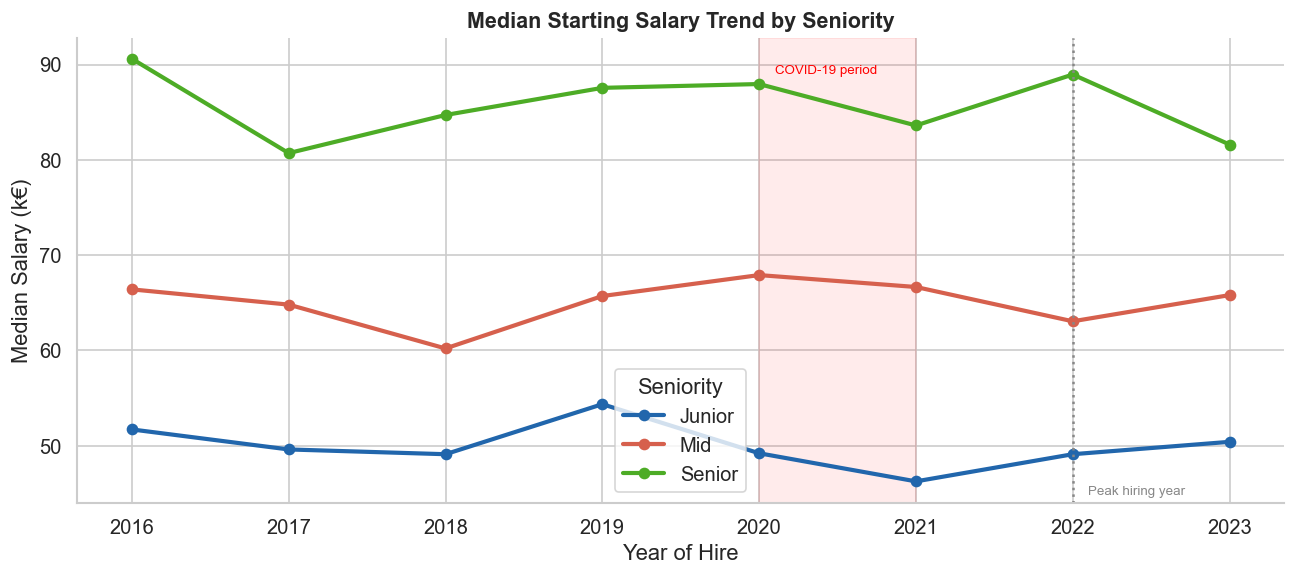

In [27]:
# Salary trend by seniority with annotations
fig, ax = plt.subplots(figsize=(11, 5))

for sen, color in zip(['Junior','Mid','Senior'], [BLUE, ORANGE, GREEN]):
    data = (
        df[df['seniority']==sen]
        .groupby(df.loc[df['seniority']==sen,'hire_date'].dt.year)['salary']
        .median() / 1000
    )
    ax.plot(data.index, data.values, lw=2.5, color=color,
            marker='o', ms=6, label=sen)

# Annotate COVID dip & recovery
ax.axvspan(2020, 2021, alpha=0.08, color='red')
ax.text(2020.1, ax.get_ylim()[1]*0.97, 'COVID-19 period',
        fontsize=8, color='red', va='top')

# Annotate peak hire year
peak_year = 2022
ax.axvline(peak_year, color=GREY, lw=1.5, ls=':')
ax.text(peak_year+0.1, ax.get_ylim()[0]*1.02, 'Peak hiring year',
        fontsize=8, color=GREY)

ax.set_xlabel('Year of Hire')
ax.set_ylabel('Median Salary (k€)')
ax.set_title('Median Starting Salary Trend by Seniority', fontweight='bold')
ax.legend(title='Seniority')
plt.tight_layout()
plt.show()


## ✏️ Exercise 7.1
Plot a **line chart** showing how `average satisfaction` evolved over hire cohort year (the year they were hired).
Shade the area between the 25th and 75th percentile to show the spread.


In [ ]:
# YOUR CODE HERE


# 🔬 Module 8 — Statistical Inference (Optional)
## 8.1 Confidence Intervals

A **95% confidence interval** means: if we repeated this study 100 times,
~95 of the intervals would contain the true population mean.

> It does **not** mean "there's a 95% chance the true mean is in this interval."


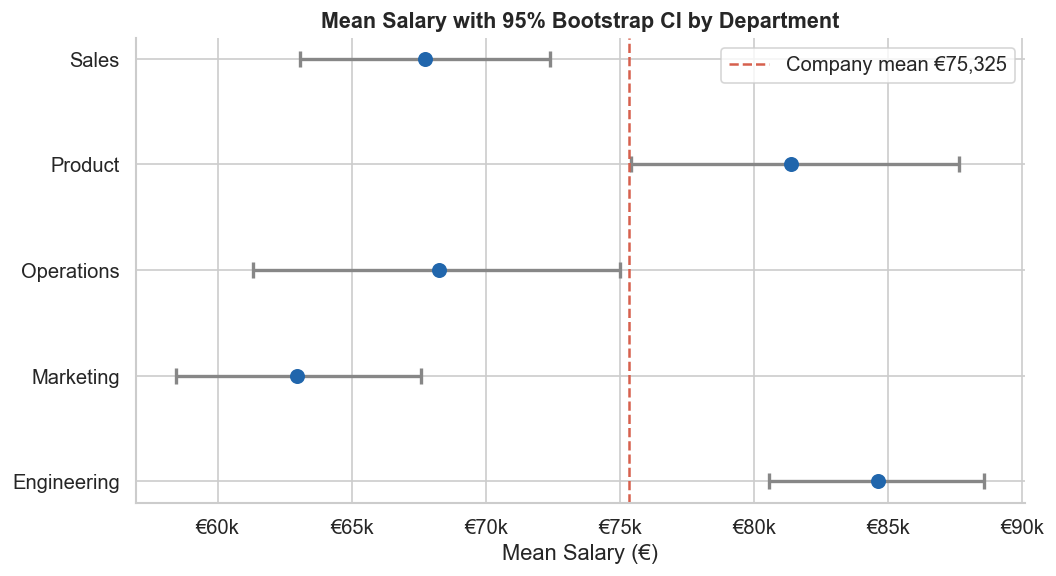

Non-overlapping CIs indicate statistically meaningful differences between departments.


In [28]:
def bootstrap_ci(data, stat_fn=np.mean, n_boot=2000, ci=95):
    """Bootstrap confidence interval for any statistic."""
    boot_stats = [stat_fn(np.random.choice(data, size=len(data), replace=True))
                  for _ in range(n_boot)]
    alpha = (100 - ci) / 2
    return np.percentile(boot_stats, [alpha, 100-alpha])

fig, ax = plt.subplots(figsize=(9, 5))

depts = df['department'].unique()
means, ci_lows, ci_highs, labels = [], [], [], []

for dept in sorted(depts):
    sal = df.loc[df['department']==dept, 'salary'].values
    lo, hi = bootstrap_ci(sal, n_boot=1000)
    means.append(np.mean(sal))
    ci_lows.append(np.mean(sal) - lo)
    ci_highs.append(hi - np.mean(sal))
    labels.append(dept)

y_pos = range(len(labels))
ax.errorbar(means, y_pos, xerr=[ci_lows, ci_highs],
            fmt='o', color=BLUE, ecolor=GREY,
            capsize=5, capthick=2, ms=8, lw=2)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels)
ax.axvline(df['salary'].mean(), color=ORANGE, lw=1.5, ls='--',
           label=f'Company mean €{df["salary"].mean():,.0f}')
ax.set_xlabel('Mean Salary (€)')
ax.set_title('Mean Salary with 95% Bootstrap CI by Department', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()
print("Non-overlapping CIs indicate statistically meaningful differences between departments.")


## 8.2 Hypothesis Testing — t-test

**Null hypothesis (H₀):** The two groups have the same population mean.
**Alternative (H₁):** They don't.

We reject H₀ if **p-value < 0.05** (5% significance level).


In [37]:
# Do employees who left have significantly different salaries?
stayed = df.loc[~df['left_company'], 'salary']
left   = df.loc[ df['left_company'], 'salary']

t_stat, p_val = stats.ttest_ind(stayed, left, equal_var=False)  # Welch's t-test

print("=== Independent Samples t-test: Salary (Stayed vs Left) ===")
print(f"  Stayed:   n={len(stayed):3d}  mean=€{stayed.mean():,.0f}  std=€{stayed.std():,.0f}")
print(f"  Left:     n={len(left):3d}  mean=€{left.mean():,.0f}  std=€{left.std():,.0f}")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:      {p_val:.4f}")
print()
if p_val < 0.05:
    direction = "higher" if stayed.mean() > left.mean() else "lower"
    print(f"  ✅ Statistically significant (p < 0.05).")
    print(f"  Employees who stayed have {direction} mean salaries.")
else:
    print(f"  ❌ Not statistically significant (p ≥ 0.05).")
    print(f"  We cannot reject that the means are equal.")


=== Independent Samples t-test: Salary (Stayed vs Left) ===
  Stayed:   n=350  mean=€77,827  std=€23,277
  Left:     n= 50  mean=€57,810  std=€23,756
  t-statistic: 5.587
  p-value:      0.0000

  ✅ Statistically significant (p < 0.05).
  Employees who stayed have higher mean salaries.


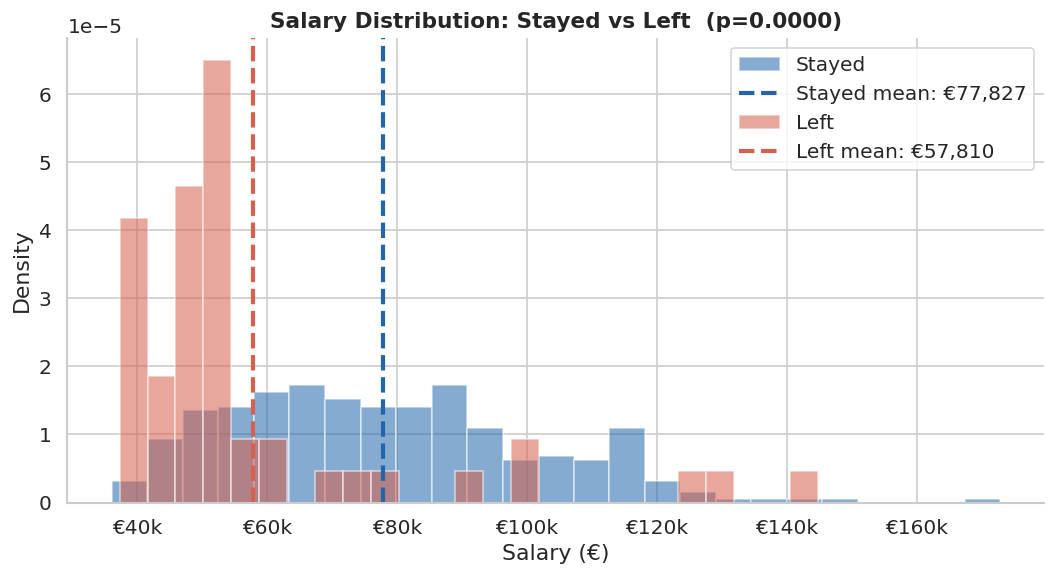

In [38]:
# Visualise the t-test result
fig, ax = plt.subplots(figsize=(9, 5))

for group, label, color in [(stayed,'Stayed',BLUE),(left,'Left',ORANGE)]:
    ax.hist(group, bins=25, alpha=0.55, color=color, edgecolor='white', label=label,
            density=True)
    ax.axvline(group.mean(), color=color, lw=2.5, ls='--',
               label=f'{label} mean: €{group.mean():,.0f}')

ax.set_xlabel('Salary (€)')
ax.set_ylabel('Density')
ax.set_title(f'Salary Distribution: Stayed vs Left  (p={p_val:.4f})', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
plt.tight_layout()
plt.show()


## 8.3 Chi-Square Test — for Categorical Variables

Tests whether two categorical variables are **independent**.


In [39]:
# Is attrition independent of department?
contingency = pd.crosstab(df['department'], df['left_company'])
print("Contingency table:")
print(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p:.4f}")
print()
if p < 0.05:
    print("✅ Significant: attrition is NOT independent of department.")
else:
    print("❌ Not significant: no evidence that attrition depends on department.")


Contingency table:
left_company  False  True 
department                
Engineering     131     16
Marketing        55     10
Operations       33      5
Product          58      4
Sales            73     15

Chi-square statistic: 4.596
Degrees of freedom:   4
p-value:              0.3313

❌ Not significant: no evidence that attrition depends on department.


## ✏️ Exercise 8.1
Test whether `performance` scores differ significantly between **Engineering** and **Sales**.

1. Compute descriptive stats for each group.
2. Run an independent t-test.
3. Visualise with overlapping KDE plots.
4. Write a one-sentence interpretation.


In [ ]:
# YOUR CODE HERE


✨ Module 9 — Interactive Charts with Plotly

## 9.1 Why Plotly?

| Feature | matplotlib/seaborn | plotly |
|---------|-------------------|--------|
| Static export (PNG/PDF) | ✅ Excellent | ✅ Good |
| Hover tooltips | ❌ | ✅ |
| Zoom / pan | ❌ | ✅ |
| Dashboards | ❌ | ✅ (Dash) |
| Animations | Difficult | ✅ |
| Learning curve | Lower | Medium |

Use plotly for **exploratory work** and **stakeholder presentations**.
Use matplotlib/seaborn for **publication-quality** static figures.

```bash
pip install plotly
```


In [51]:
# Check for plotly; provide static fallback if unavailable
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = False
    print(f"plotly {px.__doc__} ✅")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("plotly not installed. Run: pip install plotly")
    print("Showing matplotlib equivalents below.")


plotly 
`plotly.express` is a terse, consistent, high-level wrapper around `plotly.graph_objects`
for rapid data exploration and figure generation. Learn more at https://plotly.com/python/plotly-express/
 ✅


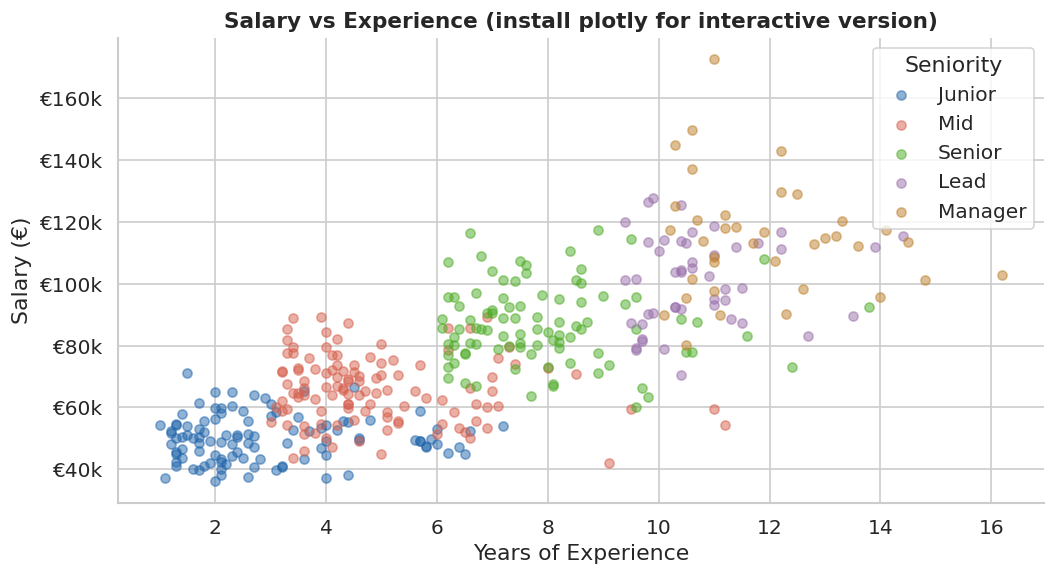

In [52]:
if PLOTLY_AVAILABLE:
    # ── Interactive scatter: salary vs experience ──────────────────────────
    fig = px.scatter(
        df,
        x='years_exp', y='salary',
        color='seniority',
        size='performance',
        hover_data=['employee_id','department','satisfaction'],
        category_orders={'seniority': ['Junior','Mid','Senior','Lead','Manager']},
        color_discrete_sequence=PALETTE,
        title='Salary vs Experience — Hover for Employee Details',
        labels={'years_exp':'Years of Experience','salary':'Annual Salary (€)'},
        trendline='ols',   # requires statsmodels
        trendline_scope='overall'
    )
    fig.update_layout(
        font_family='Arial',
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
        yaxis=dict(showgrid=True, gridcolor='#eeeeee',
                   tickformat='€,.0f'),
        legend_title_text='Seniority'
    )
    fig.show()
else:
    # Static fallback
    fig, ax = plt.subplots(figsize=(9,5))
    for i, sen in enumerate(['Junior','Mid','Senior','Lead','Manager']):
        m = df['seniority']==sen
        ax.scatter(df.loc[m,'years_exp'], df.loc[m,'salary'],
                   color=PALETTE[i], alpha=0.5, s=30, label=sen)
    ax.set_xlabel('Years of Experience'); ax.set_ylabel('Salary (€)')
    ax.set_title('Salary vs Experience (install plotly for interactive version)')
    ax.legend(title='Seniority')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
    plt.tight_layout(); plt.show()


In [53]:
if PLOTLY_AVAILABLE:
    # ── Interactive sunburst: department → seniority → headcount ──────────
    sunburst_df = df.groupby(['department','seniority'], observed=True).size().reset_index(name='count')

    fig = px.sunburst(
        sunburst_df,
        path=['department','seniority'],
        values='count',
        color='count',
        color_continuous_scale='Blues',
        title='Headcount: Department → Seniority Breakdown'
    )
    fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
    fig.show()
else:
    print("Skipping sunburst — requires plotly. Run: pip install plotly")


Skipping sunburst — requires plotly. Run: pip install plotly


In [54]:
if PLOTLY_AVAILABLE:
    # ── Interactive box plot with all data points ──────────────────────────
    fig = px.box(
        df,
        x='department', y='salary',
        color='department',
        points='all',     # show all data points
        notched=True,     # notch shows 95% CI around median
        color_discrete_sequence=PALETTE,
        title='Salary Distribution by Department (notch = 95% CI around median)',
        labels={'salary':'Annual Salary (€)', 'department':''}
    )
    fig.update_layout(showlegend=False, yaxis_tickformat='€,.0f',
                      plot_bgcolor='white')
    fig.show()
else:
    print("Skipping — requires plotly")


Skipping — requires plotly


## ✏️ Exercise 9.1
Using plotly (or matplotlib if unavailable), create an **animated bar chart** showing
the count of employees hired **per year** per **department**.

If using matplotlib, a grouped bar chart per year works fine.


In [ ]:
# YOUR CODE HERE


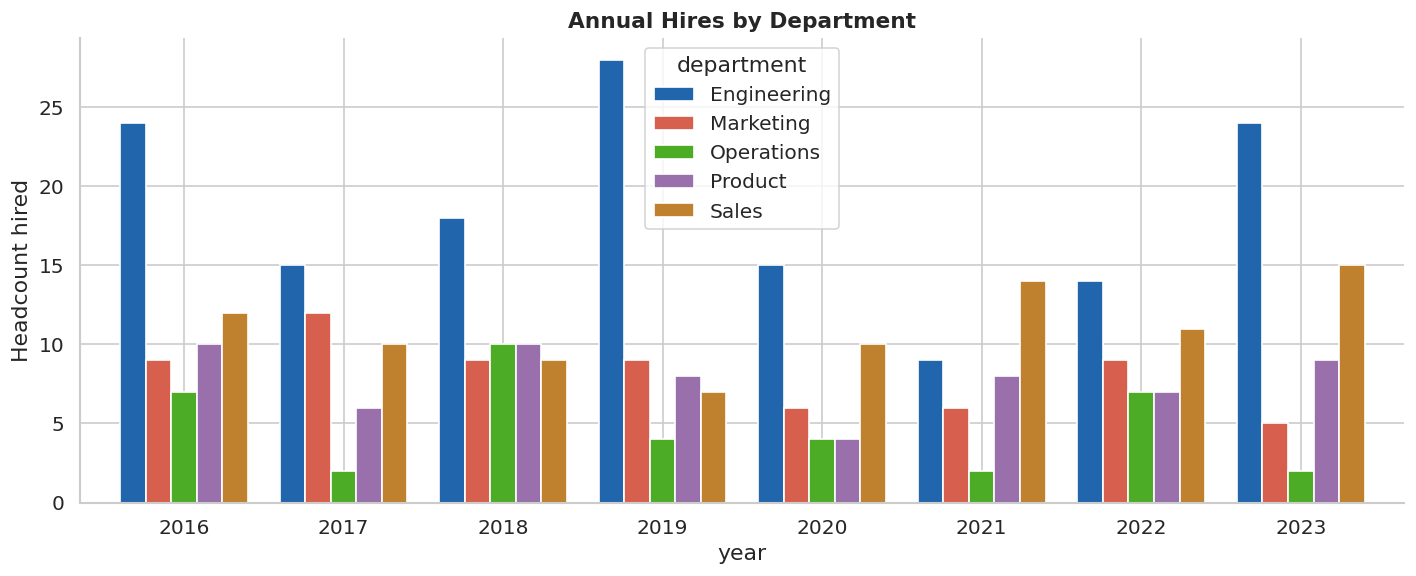

In [55]:
# 💡 SOLUTION
hire_by_year_dept = (
    df.groupby([df['hire_date'].dt.year.rename('year'), 'department'])
    .size().reset_index(name='count')
)

if PLOTLY_AVAILABLE:
    fig = px.bar(
        hire_by_year_dept.sort_values('year'),
        x='department', y='count', color='department',
        animation_frame='year',
        range_y=[0, hire_by_year_dept['count'].max() + 5],
        color_discrete_sequence=PALETTE,
        title='Hires per Department (animated by year)',
        labels={'count':'Hires','department':''}
    )
    fig.update_layout(showlegend=False)
    fig.show()
else:
    pivot = hire_by_year_dept.pivot(index='year', columns='department', values='count').fillna(0)
    pivot.plot(kind='bar', figsize=(12,5), color=PALETTE, edgecolor='white', width=0.8)
    plt.title('Annual Hires by Department')
    plt.ylabel('Headcount hired')
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()


# 🎨 Module 10 — Chart Design, Colour & Storytelling
## 10.1 The Anatomy of a Good Chart

Every chart should answer one question: **"So what?"**
If you can't write the insight as a subtitle, the chart isn't ready.

**Checklist before sharing a chart:**
- [ ] Title describes the insight, not just the data ("Engineering pays 20% more" not "Salaries")
- [ ] Axes are labelled with units
- [ ] Colour is purposeful (not just decorative)
- [ ] Colour-blind safe palette used (avoid pure red/green together)
- [ ] Source/data note present for external audiences
- [ ] No chartjunk (gridlines, borders that add nothing)


## 10.2 Colour Strategy

| Use case | Recommended | Avoid |
|----------|-------------|-------|
| Sequential data (low→high) | Blues, Oranges, Greens | Rainbow |
| Diverging (neg to pos) | RdBu, RdYlGn | Default matplotlib |
| Categorical (≤8 groups) | seaborn `muted`, `Set2` | More than 8 colours |
| Highlighting one group | Grey all others + bold one colour | Colouring everything |
| Accessibility | Okabe-Ito palette | Red + Green together |


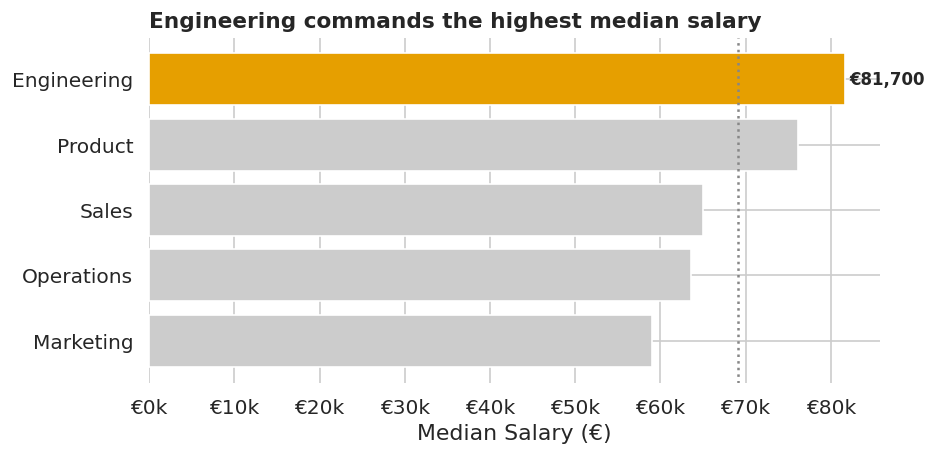

In [56]:
# Colour-blind safe Okabe-Ito palette
OKABE_ITO = ['#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7','#000000']

# Demonstrate: highlight one group in grey context
dept_median = df.groupby('department')['salary'].median().sort_values(ascending=False)
highlight = 'Engineering'

colors = [OKABE_ITO[0] if d == highlight else '#cccccc' for d in dept_median.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(dept_median.index[::-1], dept_median.values[::-1],
               color=colors[::-1], edgecolor='white')

ax.set_xlabel('Median Salary (€)')
ax.set_title('Engineering commands the highest median salary',
             fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
ax.axvline(dept_median.mean(), color=GREY, lw=1.5, ls=':', label='Dept average')

# Add value labels only on highlighted bar
for bar, dept in zip(ax.patches[::-1], dept_median.index):
    if dept == highlight:
        ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                f'€{bar.get_width():,.0f}', va='center', fontsize=10, fontweight='bold')

ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()


## 10.3 Small Multiples — Better Than a Spaghetti Chart

When you have many groups, **facet** instead of overlaying.


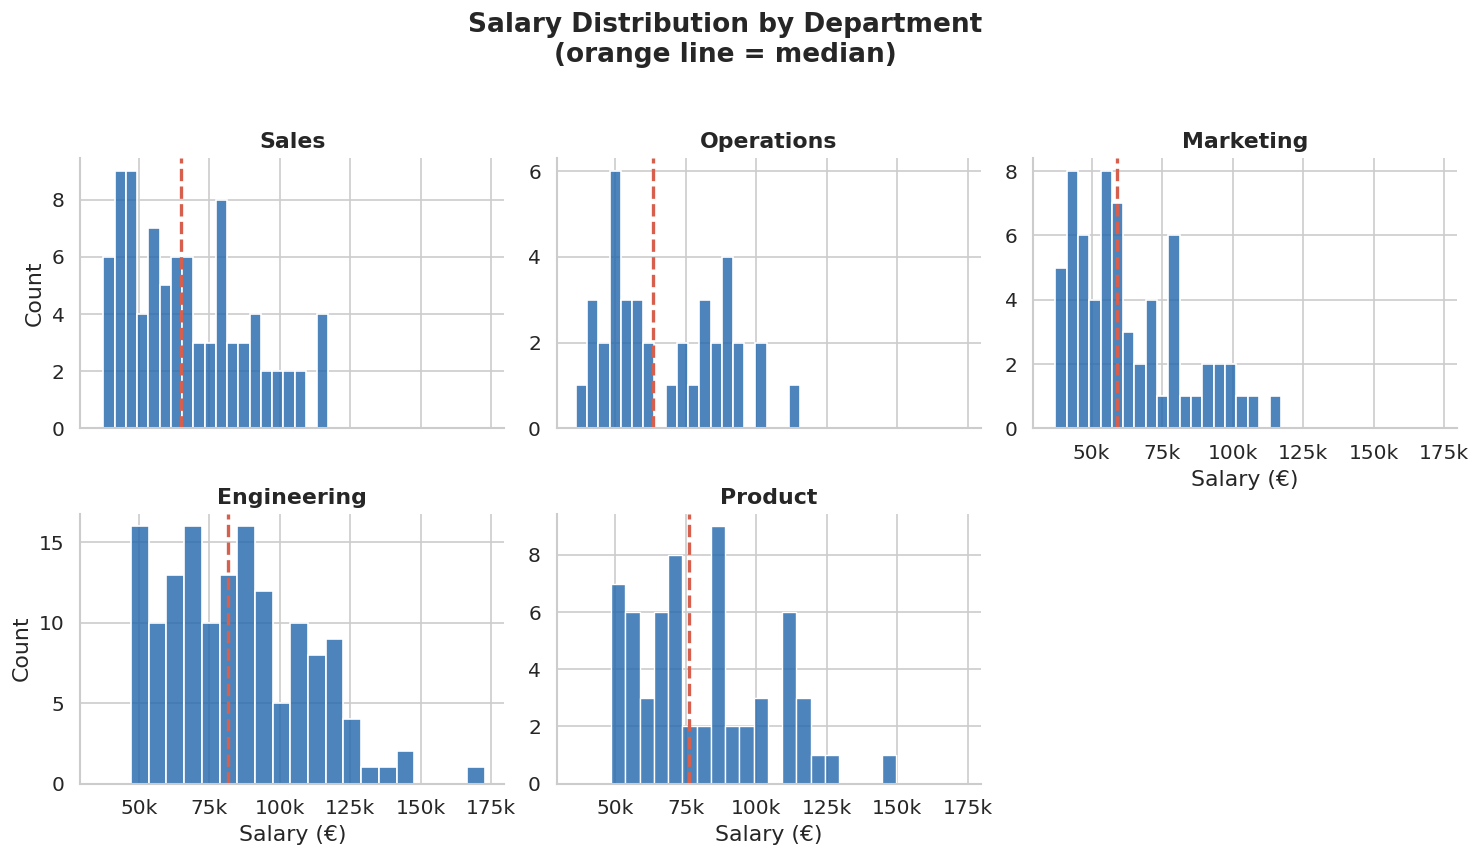

In [57]:
# Small multiples: salary distribution per department
g = sns.FacetGrid(df, col='department', col_wrap=3,
                  height=3.5, aspect=1.2, sharey=False)

g.map_dataframe(sns.histplot, x='salary', bins=20,
                color=BLUE, edgecolor='white', alpha=0.8)

g.map_dataframe(lambda data, **kw:
    plt.axvline(data['salary'].median(), color=ORANGE, lw=2, ls='--'))

g.set_axis_labels('Salary (€)', 'Count')
g.set_titles(col_template='{col_name}')

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

g.figure.suptitle('Salary Distribution by Department\n(orange line = median)',
                  fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10.4 The Finished Dashboard — Bringing It All Together


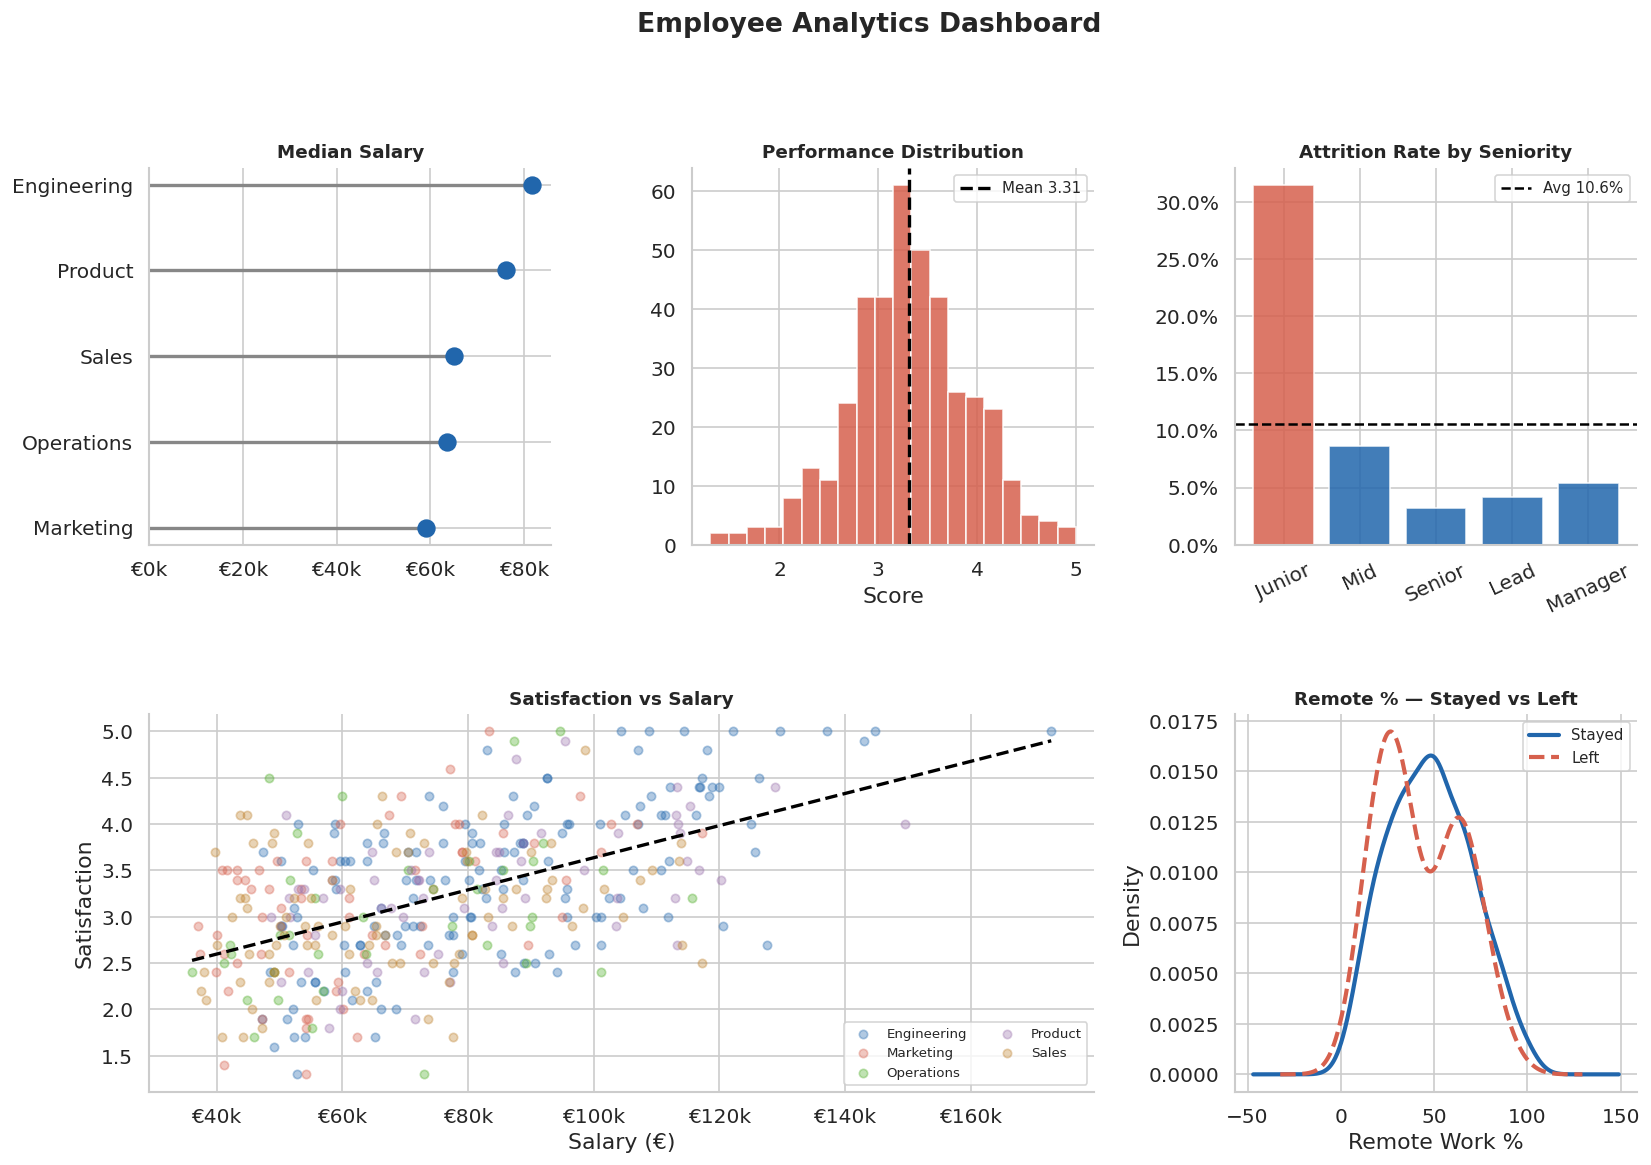

In [58]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Employee Analytics Dashboard', fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── A: Salary by dept (lollipop) ──────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
dept_sal = df.groupby('department')['salary'].median().sort_values()
ax_a.hlines(dept_sal.index, 0, dept_sal.values, color=GREY, lw=2)
ax_a.scatter(dept_sal.values, dept_sal.index, color=BLUE, s=100, zorder=3)
ax_a.set_title('Median Salary', fontweight='bold', fontsize=11)
ax_a.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))
ax_a.set_xlim(left=0)

# ── B: Performance distribution ───────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.hist(df['performance'], bins=20, color=ORANGE, edgecolor='white', alpha=0.85)
ax_b.axvline(df['performance'].mean(), color='black', lw=2, ls='--',
             label=f"Mean {df['performance'].mean():.2f}")
ax_b.set_title('Performance Distribution', fontweight='bold', fontsize=11)
ax_b.set_xlabel('Score')
ax_b.legend(fontsize=9)

# ── C: Attrition by seniority ─────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
attr = df.groupby('seniority', observed=True)['left_company'].mean().mul(100)
bars = ax_c.bar(attr.index, attr.values,
                color=[ORANGE if v > attr.mean() else BLUE for v in attr.values],
                edgecolor='white', alpha=0.85)
ax_c.axhline(attr.mean(), color='black', lw=1.5, ls='--',
             label=f"Avg {attr.mean():.1f}%")
ax_c.set_title('Attrition Rate by Seniority', fontweight='bold', fontsize=11)
ax_c.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_c.tick_params(axis='x', rotation=25)
ax_c.legend(fontsize=9)

# ── D: Satisfaction vs salary scatter ────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0:2])
for i, dept in enumerate(sorted(df['department'].unique())):
    m = df['department']==dept
    ax_d.scatter(df.loc[m,'salary'], df.loc[m,'satisfaction'],
                 color=PALETTE[i], alpha=0.35, s=25, label=dept)
m_reg, b_reg = np.polyfit(df['salary'], df['satisfaction'], 1)
x_r = np.linspace(df['salary'].min(), df['salary'].max(), 100)
ax_d.plot(x_r, m_reg*x_r + b_reg, color='black', lw=2, ls='--')
ax_d.set_xlabel('Salary (€)')
ax_d.set_ylabel('Satisfaction')
ax_d.set_title('Satisfaction vs Salary', fontweight='bold', fontsize=11)
ax_d.legend(fontsize=8, ncol=2)
ax_d.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))

# ── E: Remote % KDE ───────────────────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 2])
df[df['left_company']==False]['remote_pct'].plot.kde(
    ax=ax_e, color=BLUE, lw=2.5, label='Stayed')
df[df['left_company']==True]['remote_pct'].plot.kde(
    ax=ax_e, color=ORANGE, lw=2.5, ls='--', label='Left')
ax_e.set_xlabel('Remote Work %')
ax_e.set_title('Remote % — Stayed vs Left', fontweight='bold', fontsize=11)
ax_e.legend(fontsize=9)

plt.savefig('./tmp/dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


## ✏️ Final Challenge — Full EDA

Using the `df` employee dataset, produce a **3-chart story** that answers:

> *"What drives employee attrition at this company?"*

Requirements:
1. At least one distribution comparison
2. At least one correlation analysis
3. At least one statistical test
4. Each chart needs a **title that states the insight**, not just the variables


In [ ]:
# YOUR FINAL CHALLENGE CODE HERE
# Suggested approach:
# 1. Compare salary distributions for stayed vs left (violin or KDE)
# 2. Heatmap of correlation between numerical features and left_company (as 0/1)
# 3. Logistic-style comparison: performance × satisfaction split by left_company


## Additional Resources:
- [Understanding Skewness and Kurtosis](https://www.datacamp.com/tutorial/understanding-skewness-and-kurtosis)